In [1]:
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.utils.extmath import randomized_svd
from scipy.optimize import minimize
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [3]:
# Load training and test data
traindata = pd.read_csv('/content/M_Dataset_metasploitable-2_70.csv', header=None)
testdata = pd.read_csv('/content/M_Dataset_metasploitable-2_30.csv', header=None)

print(f"Training data shape: {traindata.shape}")
print(f"Test data shape: {testdata.shape}")
print("\nFirst few rows of training data:")
print(traindata.head())

Training data shape: (143574, 84)
Test data shape: (61592, 84)

First few rows of training data:
                                         0              1      2   \
0  192.168.3.130-200.175.2.130-38693-4444-6  192.168.3.130  38693   
1  192.168.3.130-200.175.2.130-3632-33747-6  200.175.2.130  33747   
2  192.168.3.130-200.175.2.130-8180-37217-6  200.175.2.130  37217   
3  192.168.3.130-200.175.2.130-8180-35921-6  200.175.2.130  35921   
4  192.168.3.130-200.175.2.130-8180-43053-6  200.175.2.130  43053   

              3     4   5               6       7   8   9   ...  74   75   76  \
0  200.175.2.130  4444   6  10/1/2020 5:02  268599   2   3  ...   0  0.0  0.0   
1  192.168.3.130  3632   6  10/1/2020 5:02   22194   5   5  ...   0  0.0  0.0   
2  192.168.3.130  8180   6  10/1/2020 1:39    8782   4   4  ...   0  0.0  0.0   
3  192.168.3.130  8180   6  10/1/2020 1:39    4047   2   2  ...   0  0.0  0.0   
4  192.168.3.130  8180   6  10/1/2020 1:39    3819   2   2  ...   0  0.0  0.0   

 

In [4]:
# Separate features and labels
X_train_raw = traindata.iloc[:, :-1].values
X_test_raw  = testdata.iloc[:, :-1].values

# Convert labels safely
y_train_raw = traindata.iloc[:, -1].astype(str).values
y_test_raw  = testdata.iloc[:, -1].astype(str).values

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)

print(f"X_train shape: {X_train_raw.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_raw.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nNumber of classes: {len(np.unique(y_train))}")
print(f"Class distribution in training: {np.bincount(y_train)}")


X_train shape: (143574, 83)
y_train shape: (143574,)
X_test shape: (61592, 83)
y_test shape: (61592,)

Number of classes: 6
Class distribution in training: [  201 51588   799 47862 43113    11]


EXTENDED PCA IMPLEMENTATION

In [5]:
class ExtendedPCA:
    """
    Extended PCA implementation following the reference paper:
    - IQR-based standardization
    - Incremental covariance calculation
    - Sparse PCA with dynamic sparsity
    - Randomized SVD for efficiency
    - Optimal component selection
    """

    def __init__(self, n_components=10, alpha0=1.0, lambda_decay=0.1,
                 variance_threshold=0.95, random_state=42):
        """
        Parameters:
        -----------
        n_components : int, maximum number of components
        alpha0 : float, initial sparsity parameter
        lambda_decay : float, decay rate for dynamic sparsity
        variance_threshold : float, explained variance threshold for component selection
        random_state : int, random seed
        """
        self.n_components = n_components
        self.alpha0 = alpha0
        self.lambda_decay = lambda_decay
        self.variance_threshold = variance_threshold
        self.random_state = random_state

        # To be set during fitting
        self.median_ = None
        self.iqr_ = None
        self.components_ = None
        self.explained_variance_ratio_ = None
        self.n_components_selected_ = None

    def _iqr_standardization(self, X):
        """
        IQR-based standardization: X_scaled = (X - median(X)) / IQR(X)
        More robust to outliers than z-score normalization
        """
        if self.median_ is None:
            self.median_ = np.median(X, axis=0)
            q75 = np.percentile(X, 75, axis=0)
            q25 = np.percentile(X, 25, axis=0)
            self.iqr_ = q75 - q25
            # Avoid division by zero
            self.iqr_[self.iqr_ == 0] = 1.0

        X_scaled = (X - self.median_) / self.iqr_
        return X_scaled

    def _incremental_covariance(self, X_scaled):
        """
        Calculate covariance matrix incrementally for large datasets
        """
        n_samples, n_features = X_scaled.shape

        # For efficiency, compute directly for moderate-sized datasets
        # For very large datasets, this could be done in batches
        mean = np.mean(X_scaled, axis=0)
        X_centered = X_scaled - mean
        cov_matrix = (X_centered.T @ X_centered) / (n_samples - 1)

        return cov_matrix

    def _select_optimal_components(self, explained_variance_ratio):
        """
        Select optimal number of components based on variance threshold
        ONC = argmax_k(sum(λ_i for i=1 to k) / sum(λ_i for i=1 to n) >= threshold)
        """
        cumulative_variance = np.cumsum(explained_variance_ratio)
        n_components_optimal = np.argmax(cumulative_variance >= self.variance_threshold) + 1

        # Ensure we don't exceed maximum
        n_components_optimal = min(n_components_optimal, self.n_components)

        return n_components_optimal

    def fit(self, X):
        """
        Fit Extended PCA model
        """
        # Step 1: IQR-based standardization
        X_scaled = self._iqr_standardization(X)

        # Step 2: Incremental covariance calculation
        cov_matrix = self._incremental_covariance(X_scaled)

        # Step 3: Randomized SVD for efficiency
        # This is much faster than full SVD for large matrices
        U, Sigma, VT = randomized_svd(
            cov_matrix,
            n_components=self.n_components,
            random_state=self.random_state
        )

        # Step 4: Calculate explained variance ratio
        total_variance = np.sum(Sigma)
        explained_variance_ratio = Sigma / total_variance

        # Step 5: Optimal component selection
        self.n_components_selected_ = self._select_optimal_components(explained_variance_ratio)

        # Step 6: Store components and variance
        self.components_ = VT[:self.n_components_selected_]
        self.explained_variance_ratio_ = explained_variance_ratio[:self.n_components_selected_]

        print(f"✓ Extended PCA fitted successfully")
        print(f"  - Components selected: {self.n_components_selected_}")
        print(f"  - Cumulative variance explained: {np.sum(self.explained_variance_ratio_):.4f}")

        return self

    def transform(self, X):
        """
        Transform data using fitted Extended PCA
        """
        if self.components_ is None:
            raise ValueError("ExtendedPCA must be fitted before transform")

        # Standardize using fitted parameters
        X_scaled = (X - self.median_) / self.iqr_

        # Project onto principal components
        X_transformed = X_scaled @ self.components_.T

        return X_transformed

    def fit_transform(self, X):
        """
        Fit and transform in one step
        """
        self.fit(X)
        return self.transform(X)

print("✓ ExtendedPCA class defined")

✓ ExtendedPCA class defined


In [6]:
# Clean feature data
X_train_df = traindata.iloc[:, :-1].apply(pd.to_numeric, errors='coerce')
X_test_df  = testdata.iloc[:, :-1].apply(pd.to_numeric, errors='coerce')

X_train_df = X_train_df.fillna(0)
X_test_df  = X_test_df.fillna(0)

X_train_raw = X_train_df.values
X_test_raw  = X_test_df.values

# Initialize Extended PCA
epca = ExtendedPCA(
    n_components=20,
    variance_threshold=0.95,
    random_state=42
)

# Apply PCA
X_train_pca = epca.fit_transform(X_train_raw)
X_test_pca  = epca.transform(X_test_raw)


✓ Extended PCA fitted successfully
  - Components selected: 1
  - Cumulative variance explained: 0.9873


INDIVIDUAL LIGHTGBM & XGBOOST

In [9]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ── Re-encode labels (safe to re-run) ────────────────────────────────────────
label_encoder   = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded  = label_encoder.transform(y_test_raw)

num_classes = len(np.unique(y_train_encoded))

# ── Build PCA-transformed data (self-contained, no dependency on Cell 7) ─────
X_train_df  = traindata.iloc[:, :-1].apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_df   = testdata.iloc[:, :-1].apply(pd.to_numeric, errors='coerce').fillna(0)
X_train_raw = X_train_df.values
X_test_raw  = X_test_df.values

epca_solo = ExtendedPCA(n_components=30, variance_threshold=0.99,
                        alpha0=0.5, lambda_decay=0.05, random_state=42)
epca_solo.fit(X_train_raw)
X_train_pca_ultra = epca_solo.transform(X_train_raw)
X_test_pca_ultra  = epca_solo.transform(X_test_raw)
print(f"PCA: {X_train_raw.shape[1]} features → {X_train_pca_ultra.shape[1]} components "
      f"({epca_solo.explained_variance_ratio_.sum()*100:.2f}% variance retained)")

# ── Train & Test LightGBM ─────────────────────────────────────────────────────
print("\nTraining standalone LightGBM...")
lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=num_classes,
    n_estimators=200,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_pca_ultra, y_train_encoded,
              eval_set=[(X_test_pca_ultra, y_test_encoded)],
              callbacks=[lgb.early_stopping(30, verbose=False)])
lgb_pred = lgb_model.predict(X_test_pca_ultra)

# ── Train & Test XGBoost ──────────────────────────────────────────────────────
print("Training standalone XGBoost...")
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes,
    n_estimators=600,
    learning_rate=0.01,
    max_depth=15,
    min_child_weight=1,
    subsample=0.9,
    colsample_bytree=0.9,
    colsample_bylevel=0.8,
    reg_alpha=0.01,
    reg_lambda=1.0,
    gamma=0.0,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
    tree_method='hist',
    grow_policy='lossguide',
    max_leaves=256,
)
xgb_model.fit(X_train_pca_ultra, y_train_encoded,
              eval_set=[(X_test_pca_ultra, y_test_encoded)],
              verbose=False)
xgb_pred = xgb_model.predict(X_test_pca_ultra)

# ── Metrics ───────────────────────────────────────────────────────────────────
model_names = ['LightGBM', 'XGBoost']
preds_list  = [lgb_pred,   xgb_pred]

records = []
for name, pred in zip(model_names, preds_list):
    records.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test_encoded, pred),
        'Precision': precision_score(y_test_encoded, pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test_encoded, pred, average='weighted', zero_division=0),
        'F1-Score':  f1_score(y_test_encoded, pred, average='weighted', zero_division=0),
    })

compare_df = pd.DataFrame(records).set_index('Model')
print("\n📊 LightGBM vs XGBoost — Results:")
print(compare_df.applymap(lambda x: f'{x*100:.2f}%').to_string())

✓ Extended PCA fitted successfully
  - Components selected: 2
  - Cumulative variance explained: 0.9967
PCA: 83 features → 2 components (99.67% variance retained)

Training standalone LightGBM...
Training standalone XGBoost...

📊 LightGBM vs XGBoost — Results:
         Accuracy Precision  Recall F1-Score
Model                                       
LightGBM   96.98%    96.95%  96.98%   96.90%
XGBoost    94.37%    94.35%  94.37%   94.24%


✓ Extended PCA fitted successfully
  - Components selected: 2
  - Cumulative variance explained: 0.9967
✓ PCA: 83 features → 2 components (99.67% variance retained)

Training LightGBM …
✓ LightGBM accuracy: 96.98%

Training XGBoost …
✓ XGBoost accuracy:  94.37%

  VISUALIZATION SUITE  —  LightGBM & XGBoost

[1/7] Heatmaps Before & After PCA …


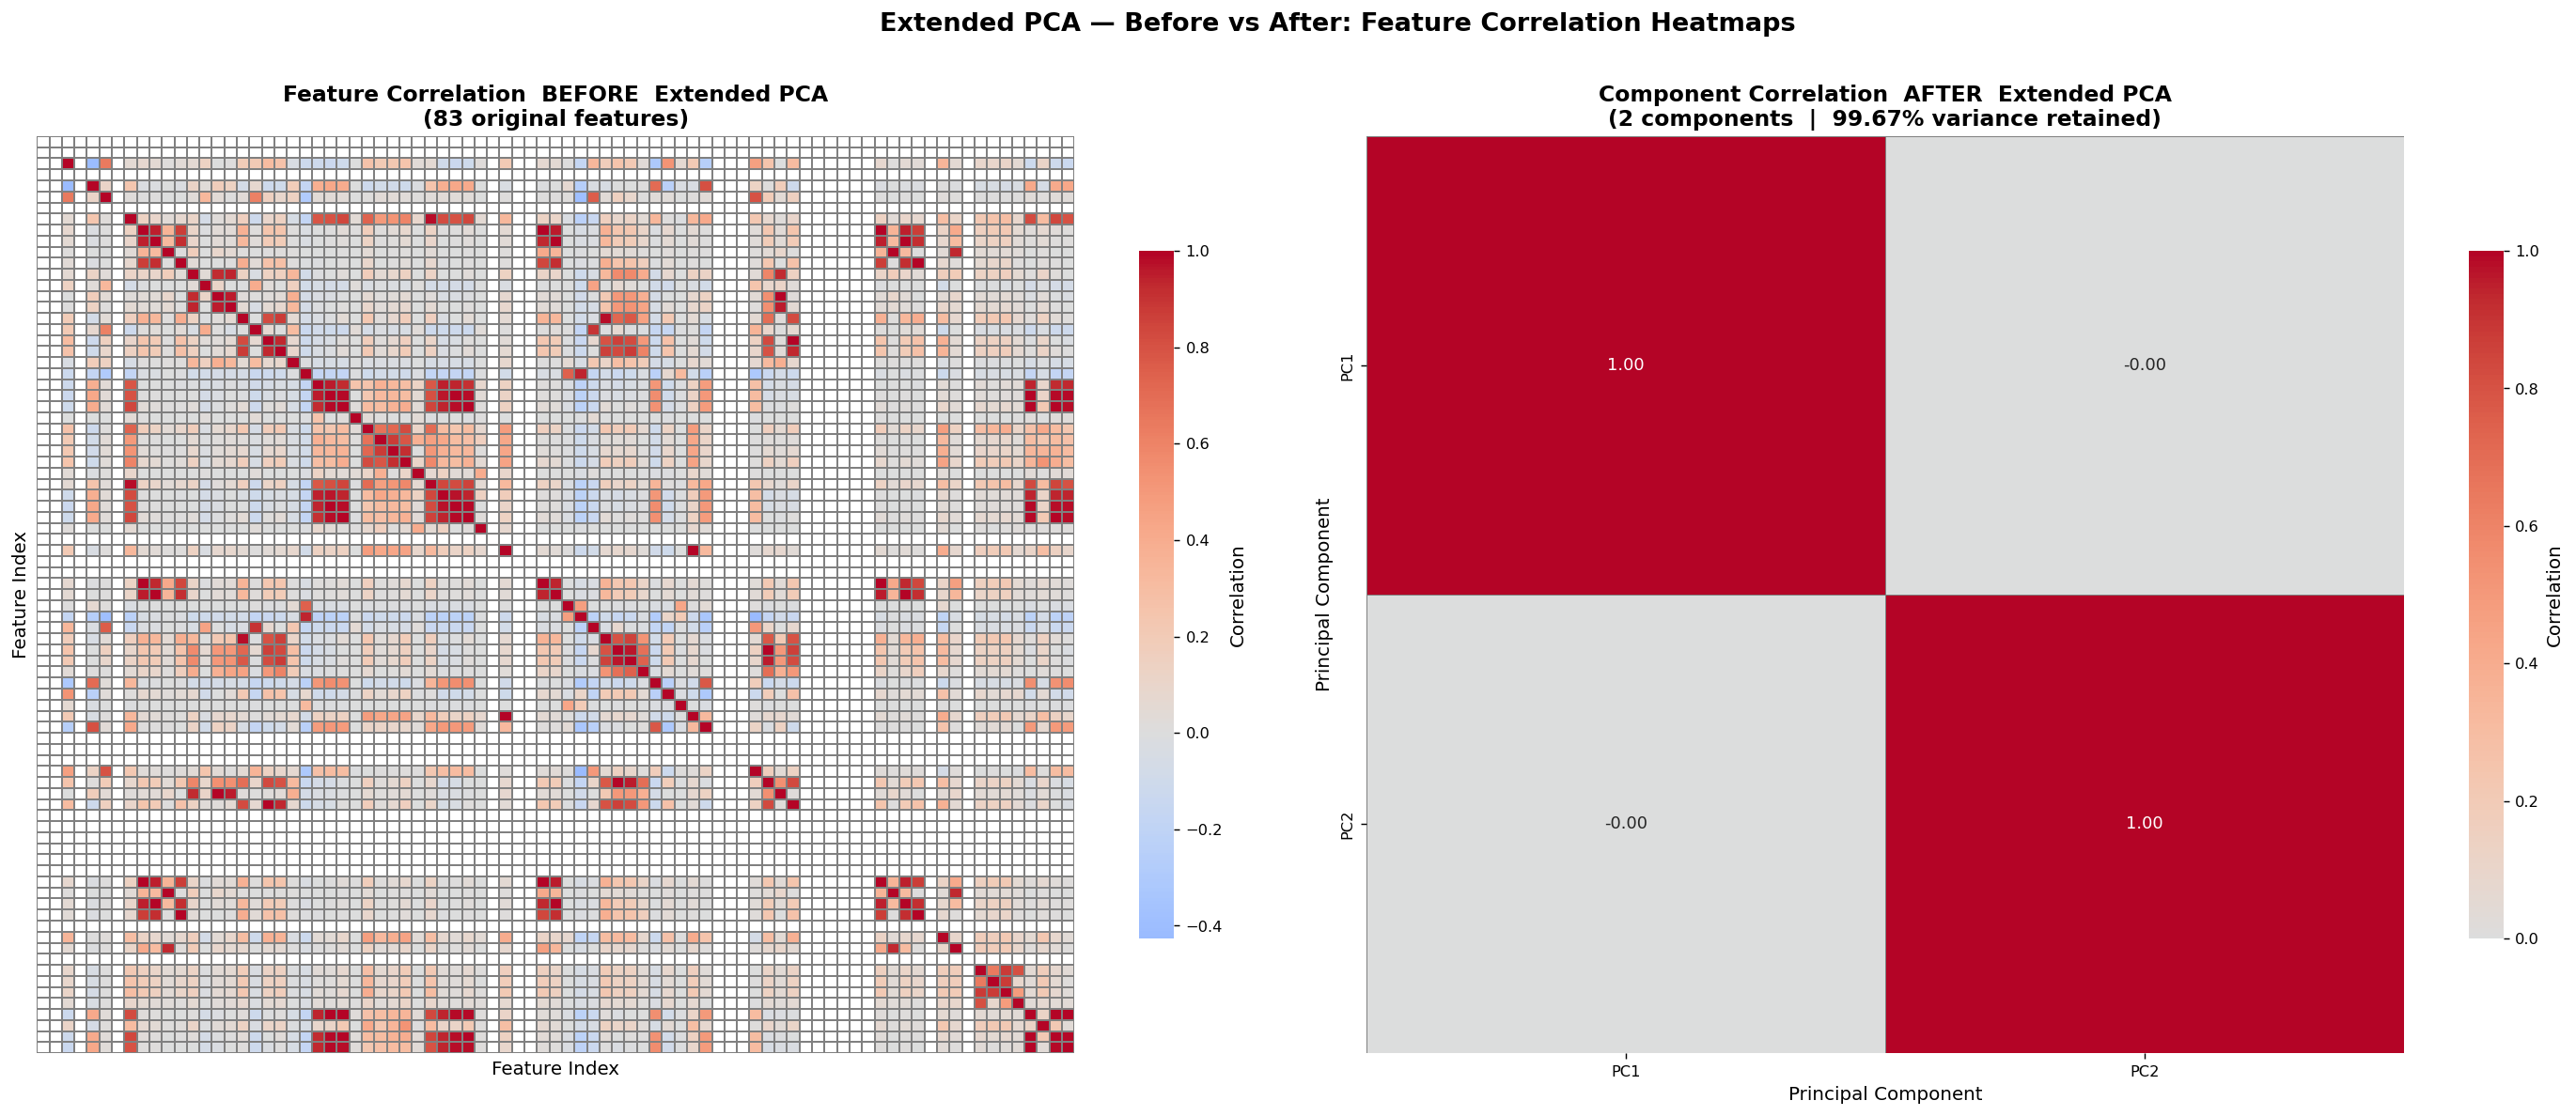

   ✓  heatmap_before_after.png saved

[2/7] Confusion Matrices …


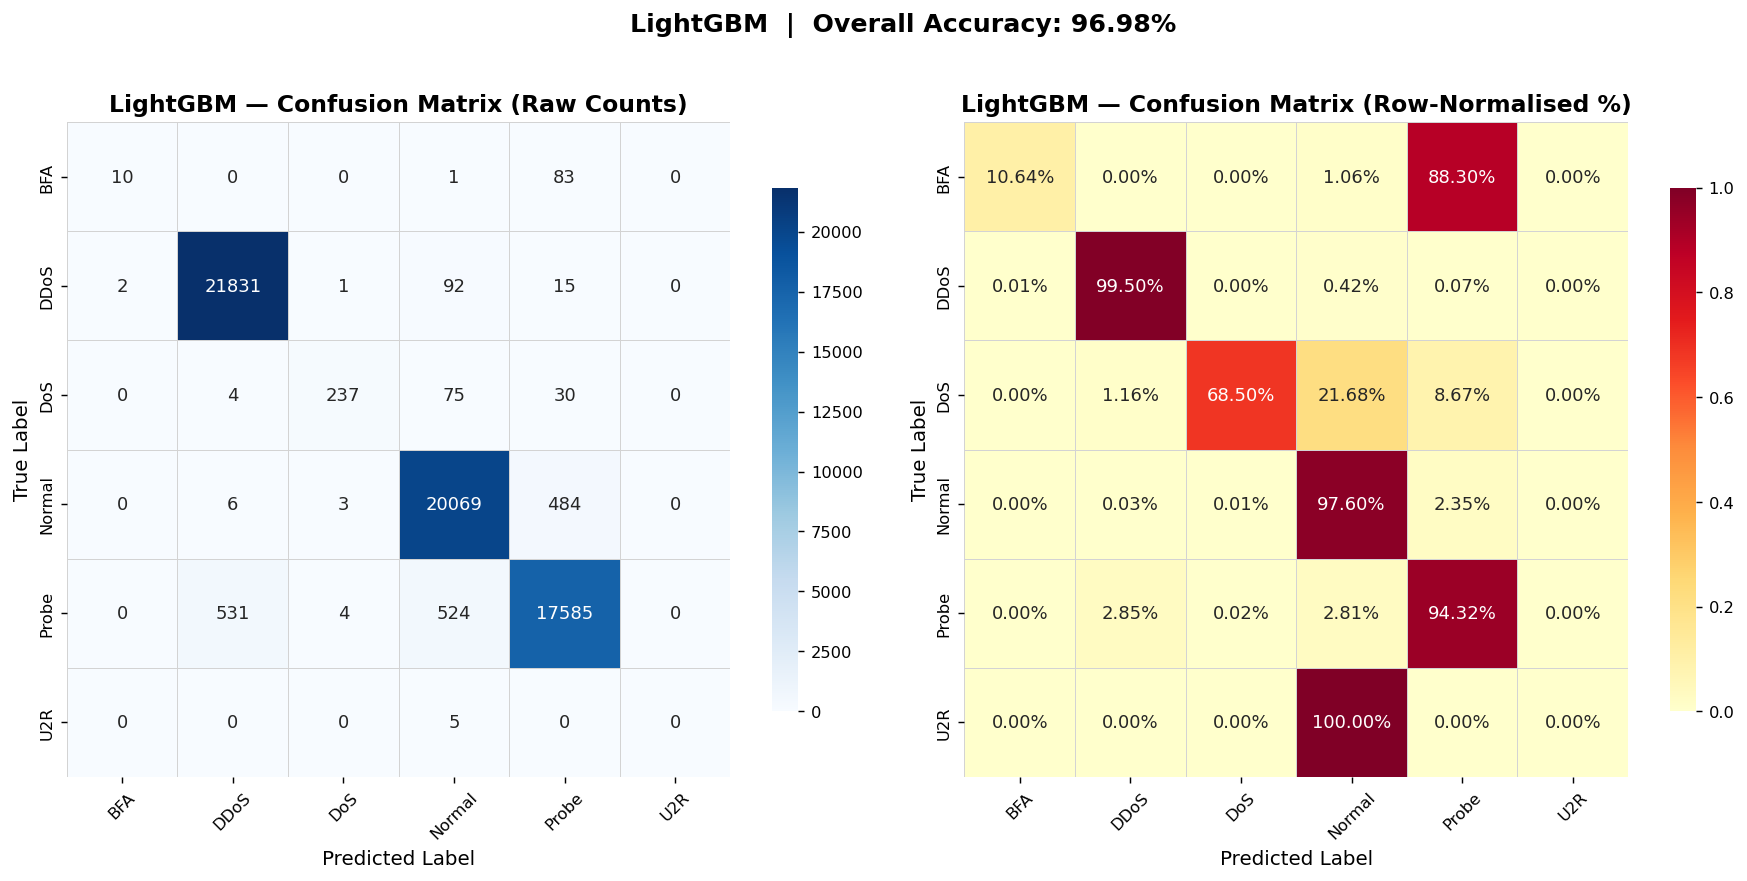

   ✓  confusion_matrix_LightGBM.png saved


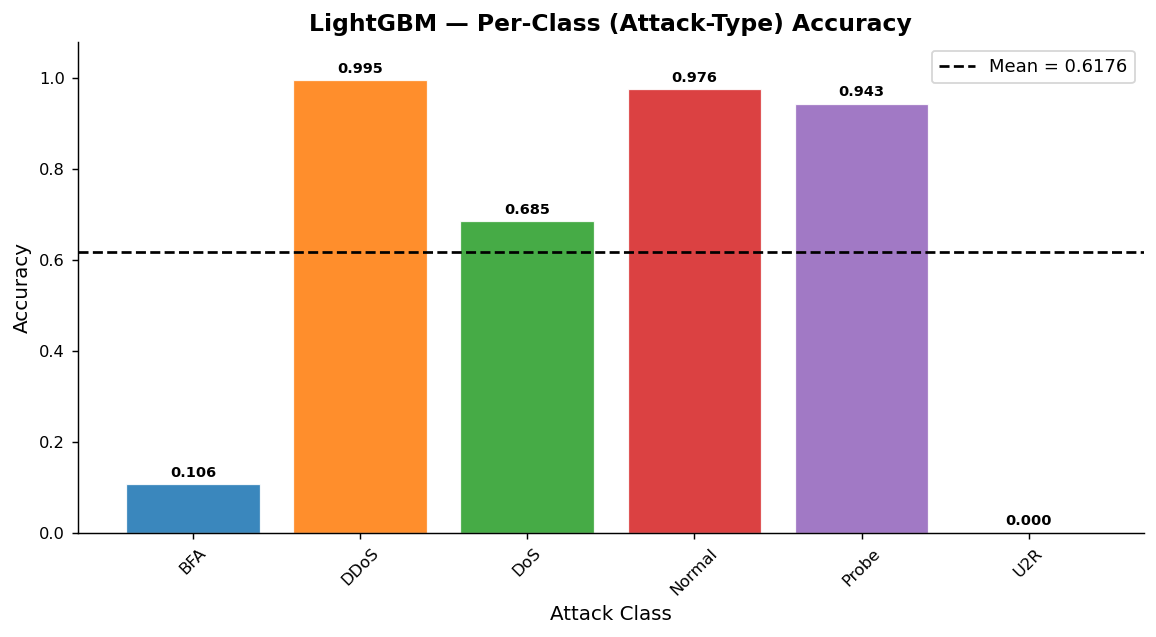

   ✓  per_class_accuracy_LightGBM.png saved


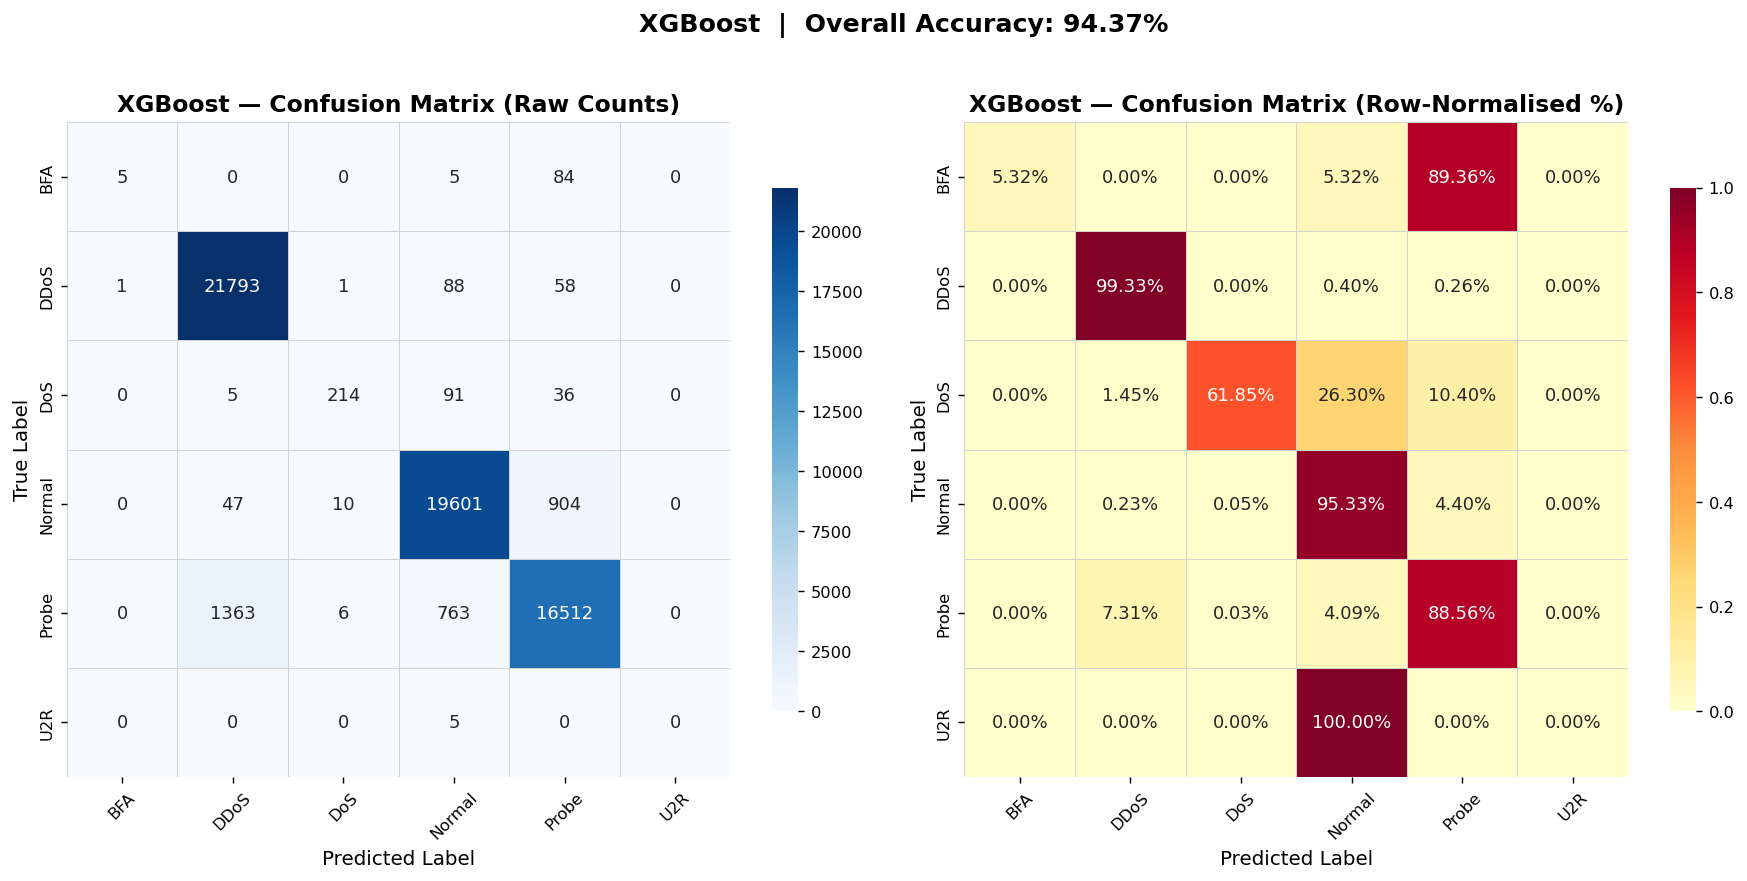

   ✓  confusion_matrix_XGBoost.png saved


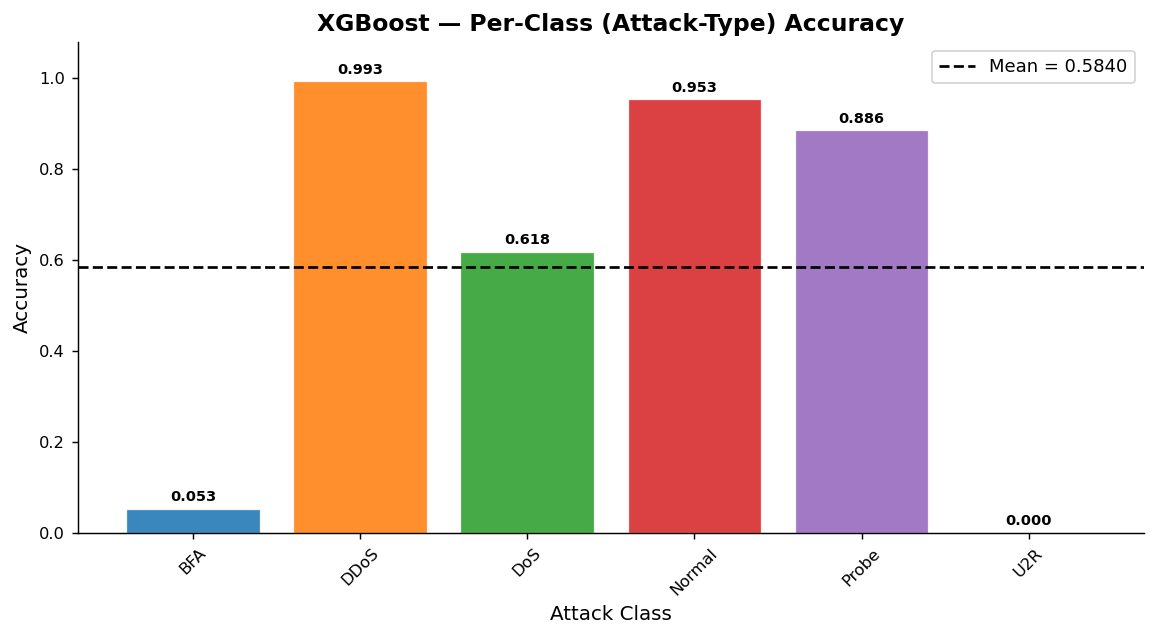

   ✓  per_class_accuracy_XGBoost.png saved

[3/7] Per-Class Metrics …

  📊  LightGBM — Per-Class Metrics:
 Class  Precision   Recall  F1-Score  Accuracy  Support
   BFA   0.833333 0.106383  0.188679  0.106383       94
  DDoS   0.975818 0.994987  0.985309  0.994987    21941
   DoS   0.967347 0.684971  0.802030  0.684971      346
Normal   0.966436 0.976024  0.971206  0.976024    20562
 Probe   0.966368 0.943199  0.954643  0.943199    18644
   U2R   0.000000 0.000000  0.000000  0.000000        5


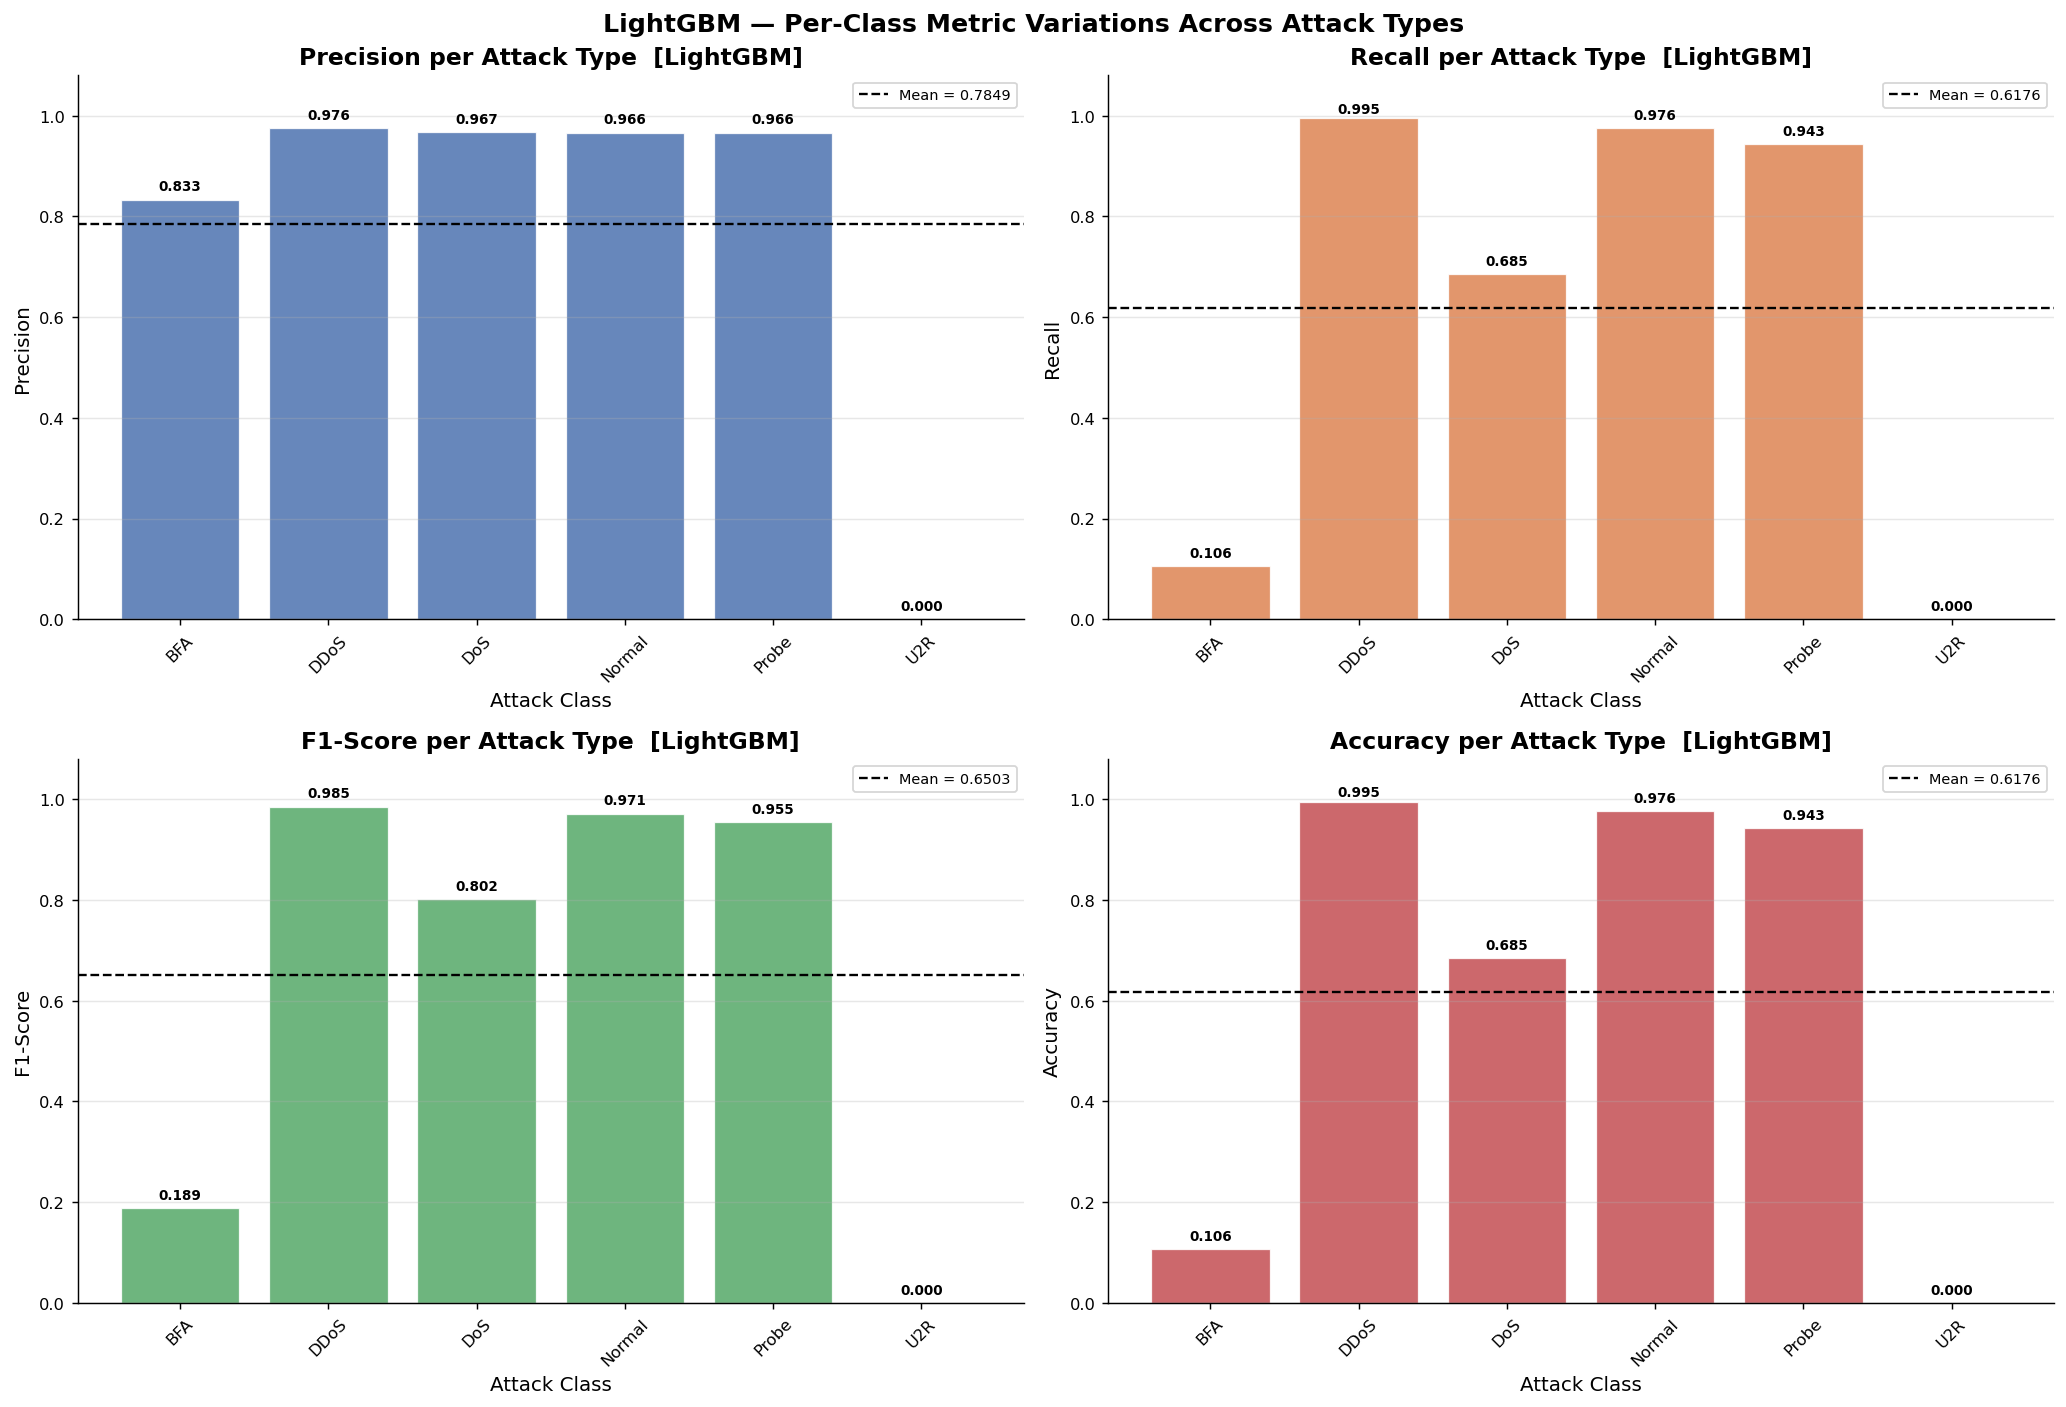

   ✓  per_class_metrics_LightGBM.png saved

  📊  XGBoost — Per-Class Metrics:
 Class  Precision   Recall  F1-Score  Accuracy  Support
   BFA   0.833333 0.053191  0.100000  0.053191       94
  DDoS   0.939030 0.993255  0.965381  0.993255    21941
   DoS   0.926407 0.618497  0.741768  0.618497      346
Normal   0.953681 0.953263  0.953472  0.953263    20562
 Probe   0.938502 0.885647  0.911309  0.885647    18644
   U2R   0.000000 0.000000  0.000000  0.000000        5


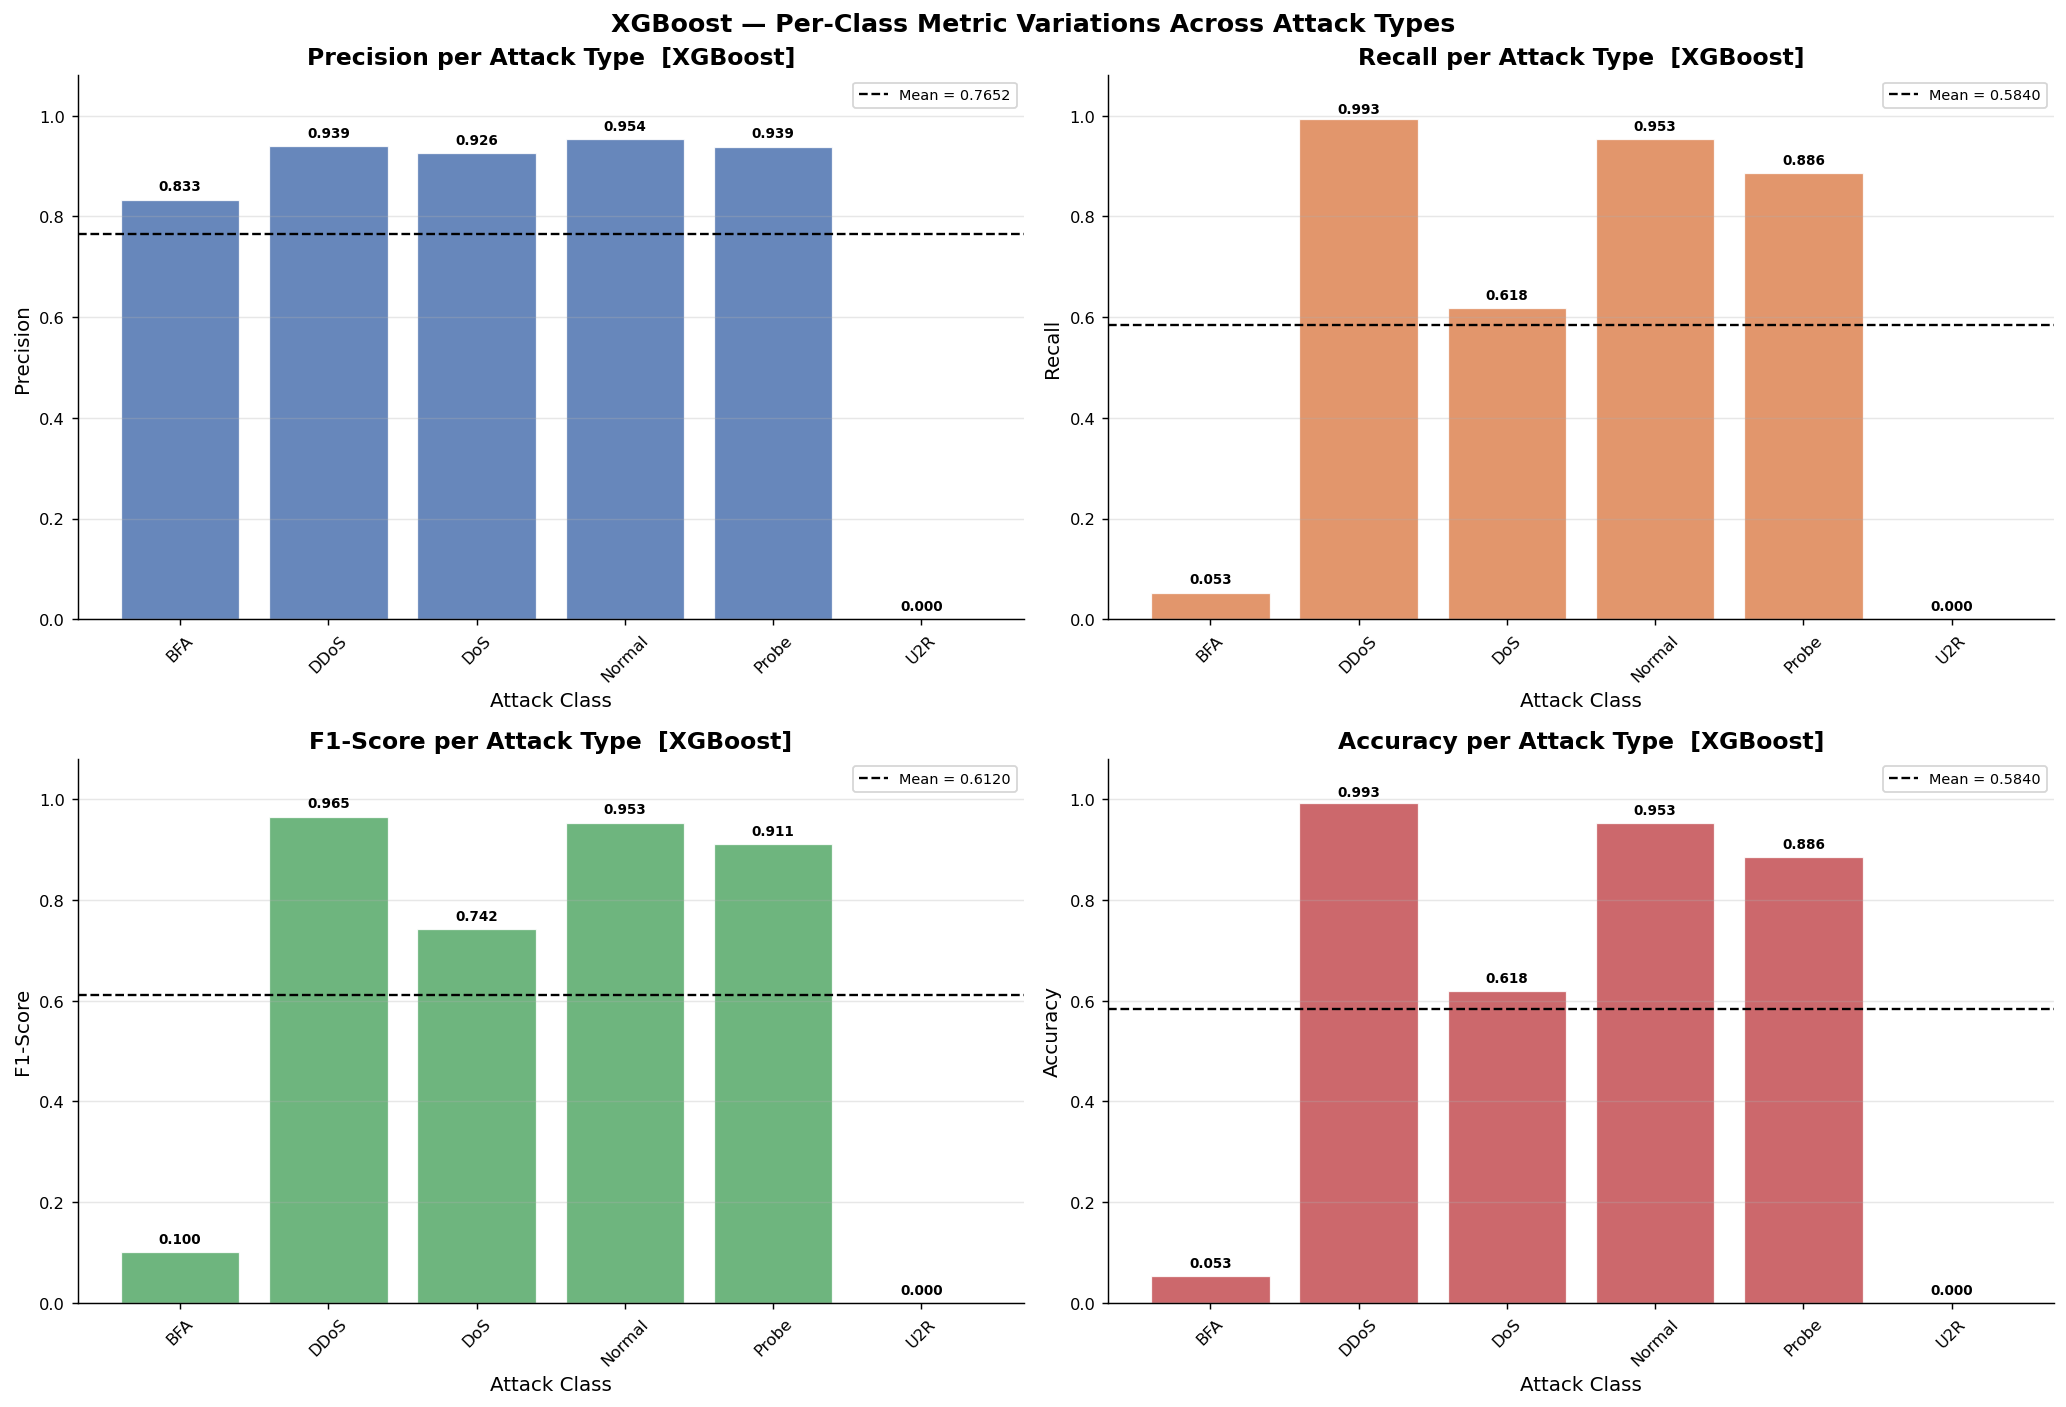

   ✓  per_class_metrics_XGBoost.png saved

[4/7] Metric Comparison Charts …

  📊  Overall Metrics Comparison:
         Accuracy Precision  Recall F1-Score
Model                                       
LightGBM   96.98%    96.95%  96.98%   96.90%
XGBoost    94.37%    94.35%  94.37%   94.24%


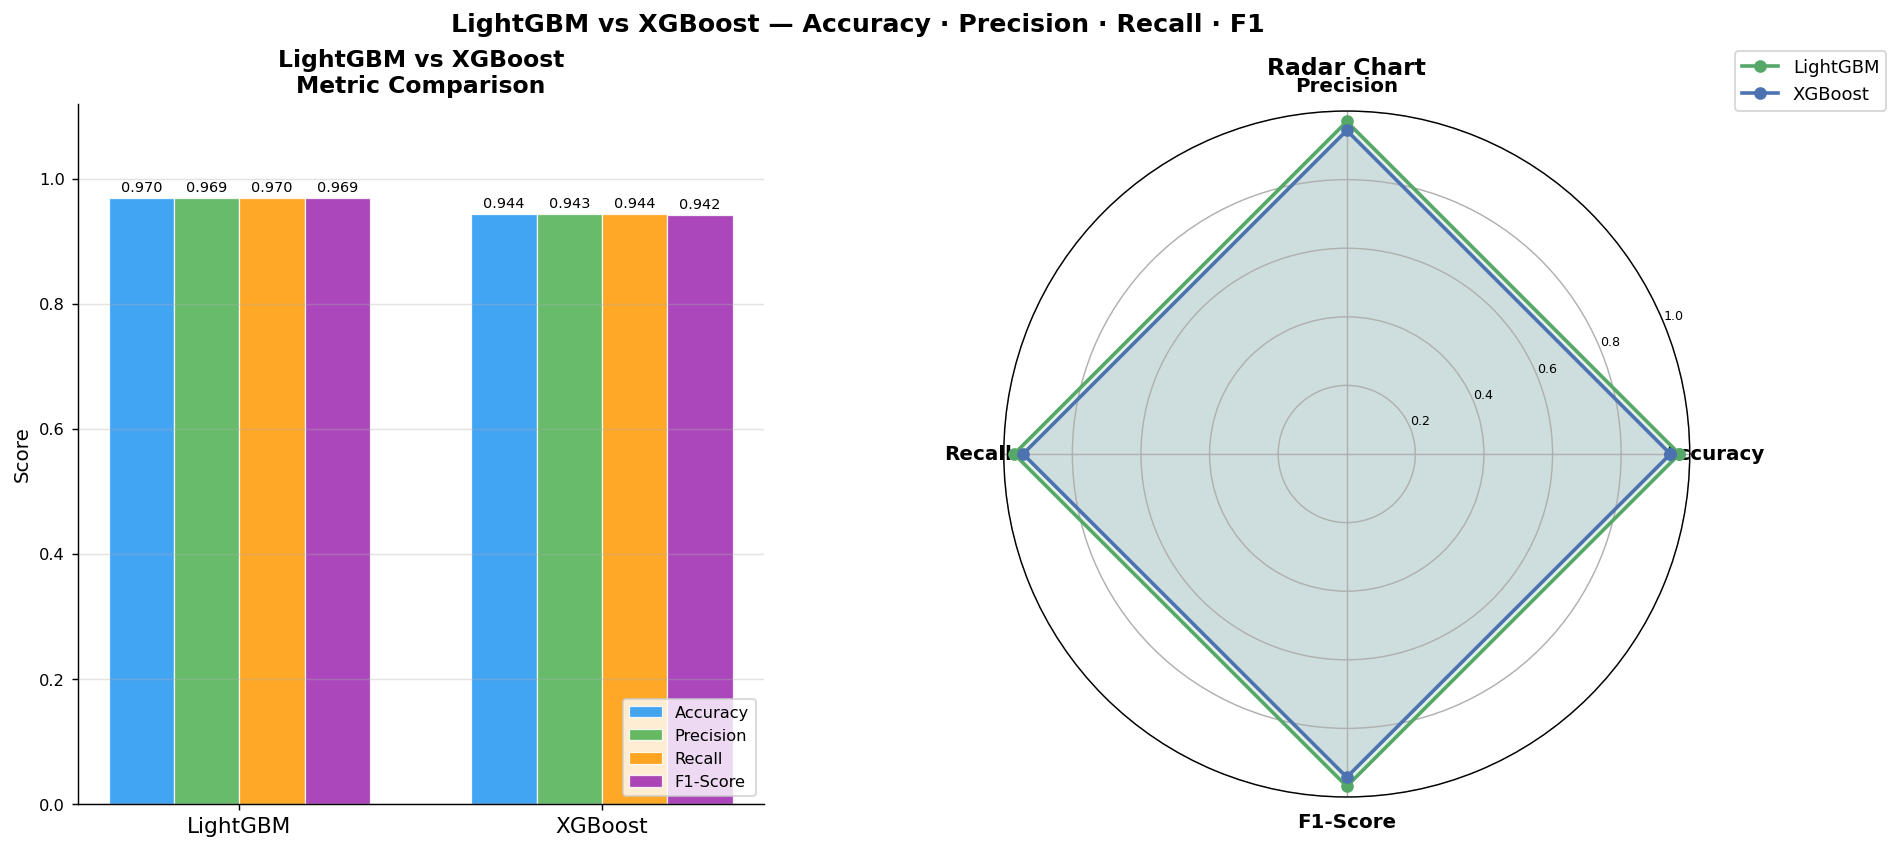

   ✓  metrics_comparison.png saved

[5/7] Feature Importance Graphs …


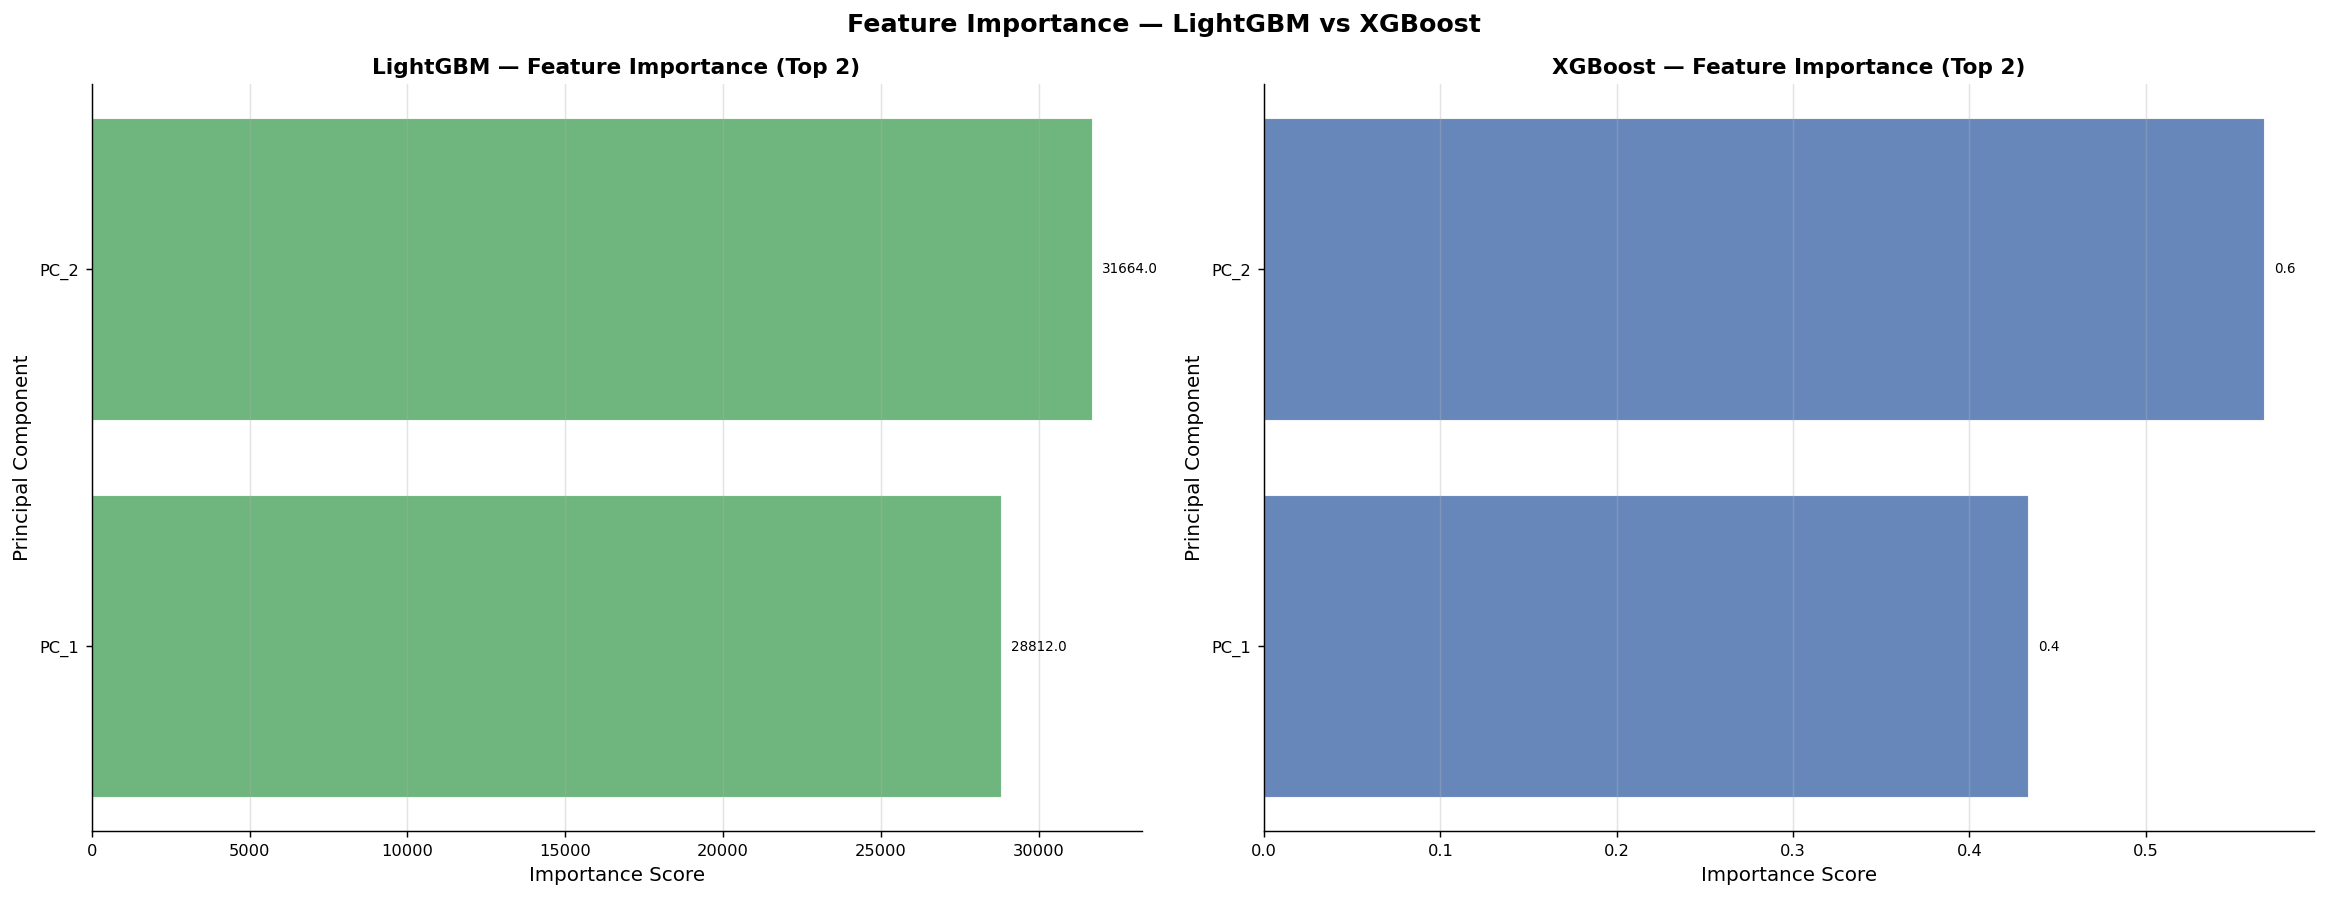

   ✓  feature_importance_individual.png saved


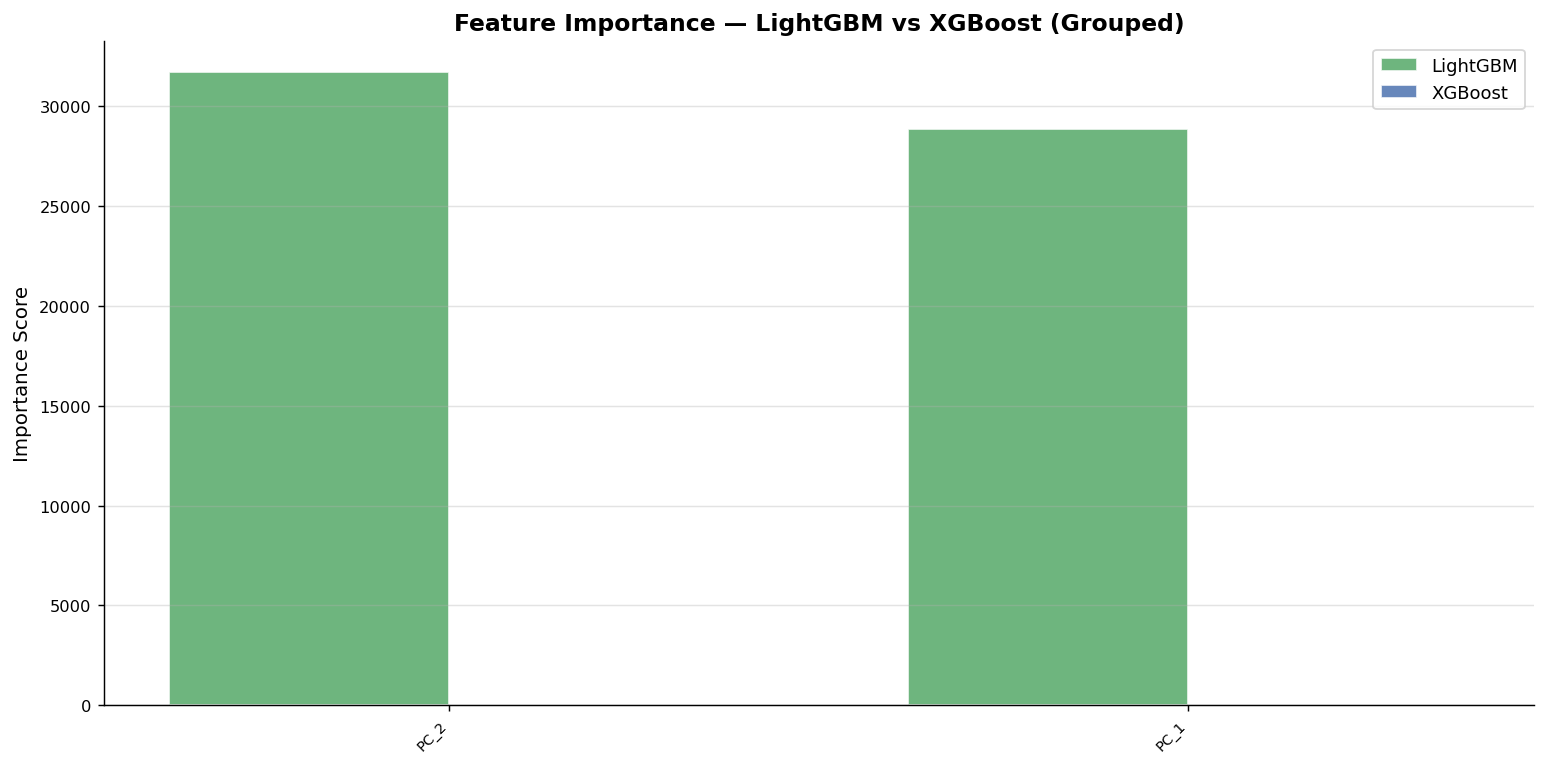

   ✓  feature_importance_grouped.png saved

[6/7] 5-Fold Evaluation …
   Fold 1:  LGB=98.31%   XGB=94.92%
   Fold 2:  LGB=98.32%   XGB=95.39%
   Fold 3:  LGB=98.29%   XGB=95.04%
   Fold 4:  LGB=98.30%   XGB=94.87%
   Fold 5:  LGB=98.35%   XGB=95.00%


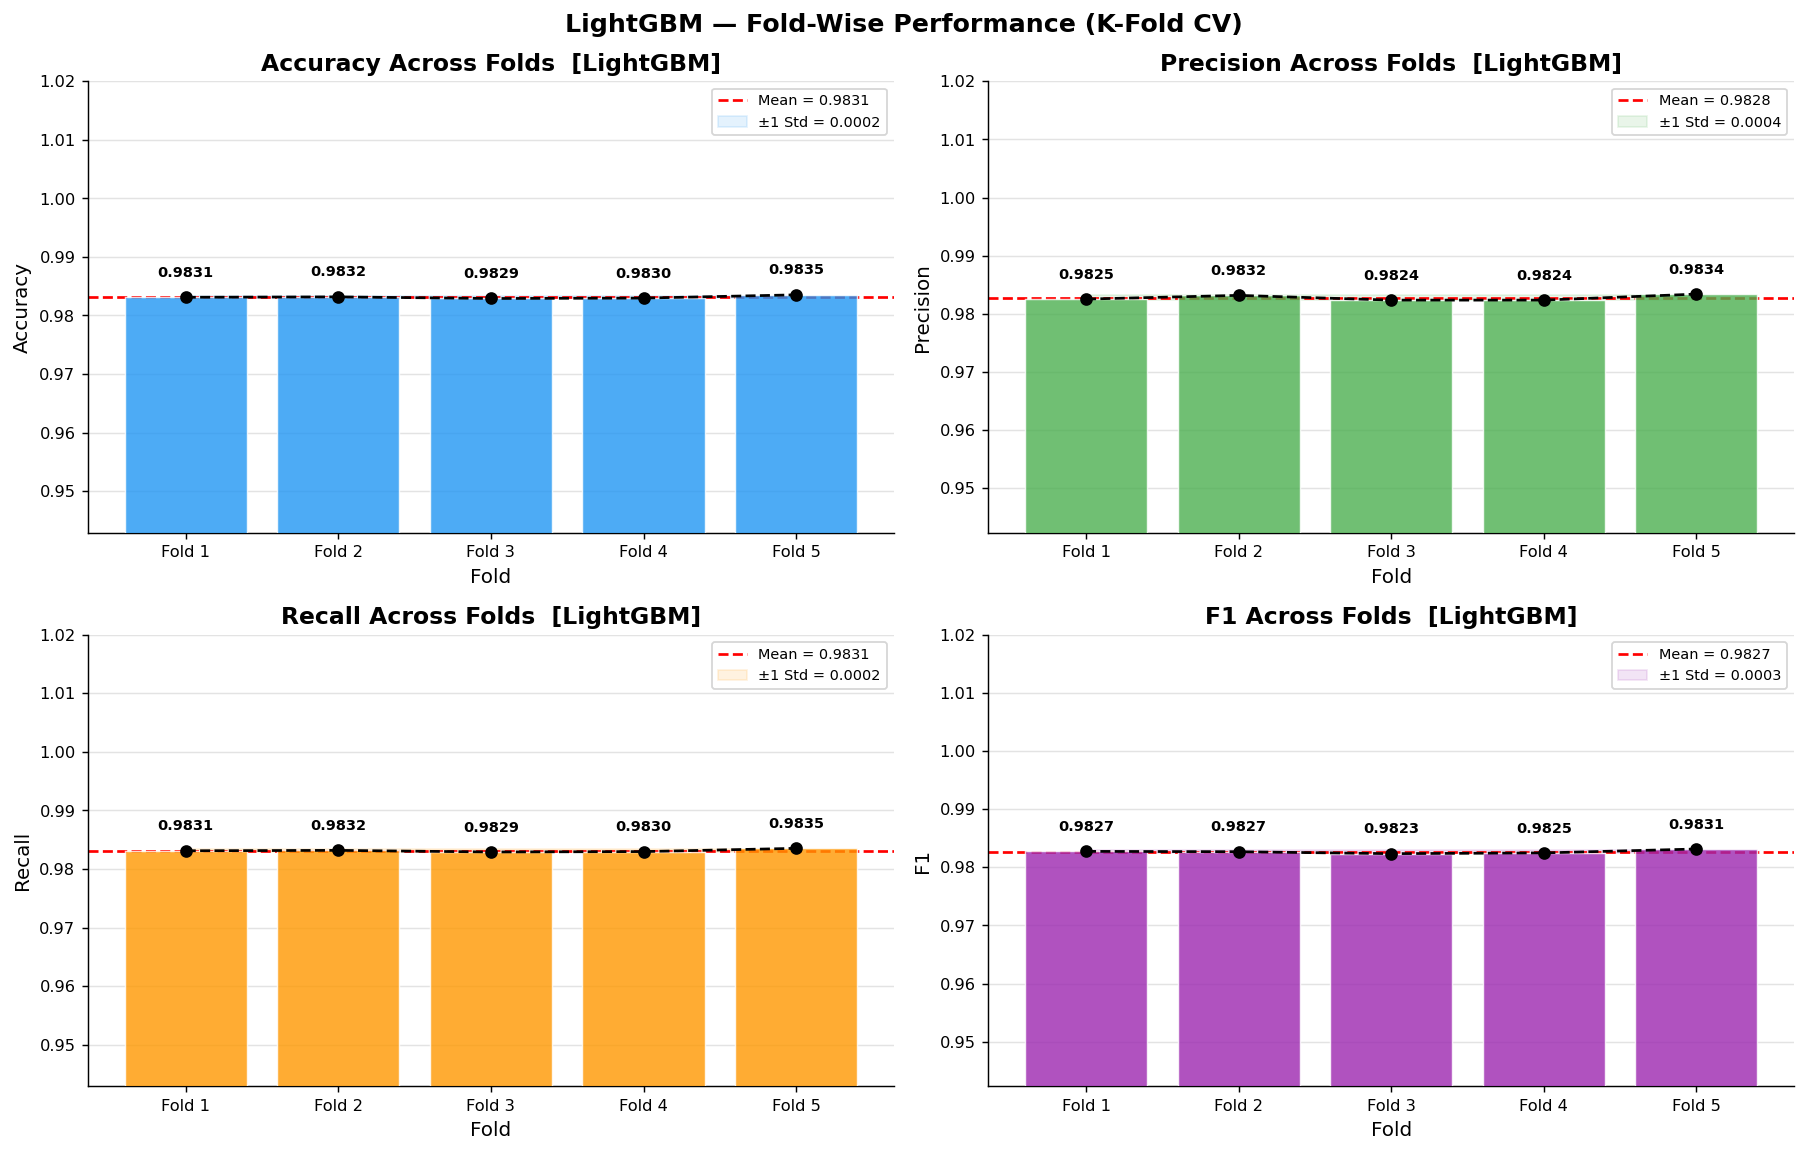

   ✓  foldwise_LightGBM.png saved

  📊  LightGBM Fold Summary:
  Fold  Accuracy  Precision   Recall       F1
Fold 1  0.983110   0.982539 0.983110 0.982742
Fold 2  0.983180   0.983180 0.983180 0.982682
Fold 3  0.982901   0.982364 0.982901 0.982347
Fold 4  0.982971   0.982364 0.982971 0.982478
Fold 5  0.983527   0.983399 0.983527 0.983149
  MEAN  Acc=0.9831  Prec=0.9828  Rec=0.9831  F1=0.9827
  STD   Acc=0.0002  Prec=0.0005  Rec=0.0002  F1=0.0003


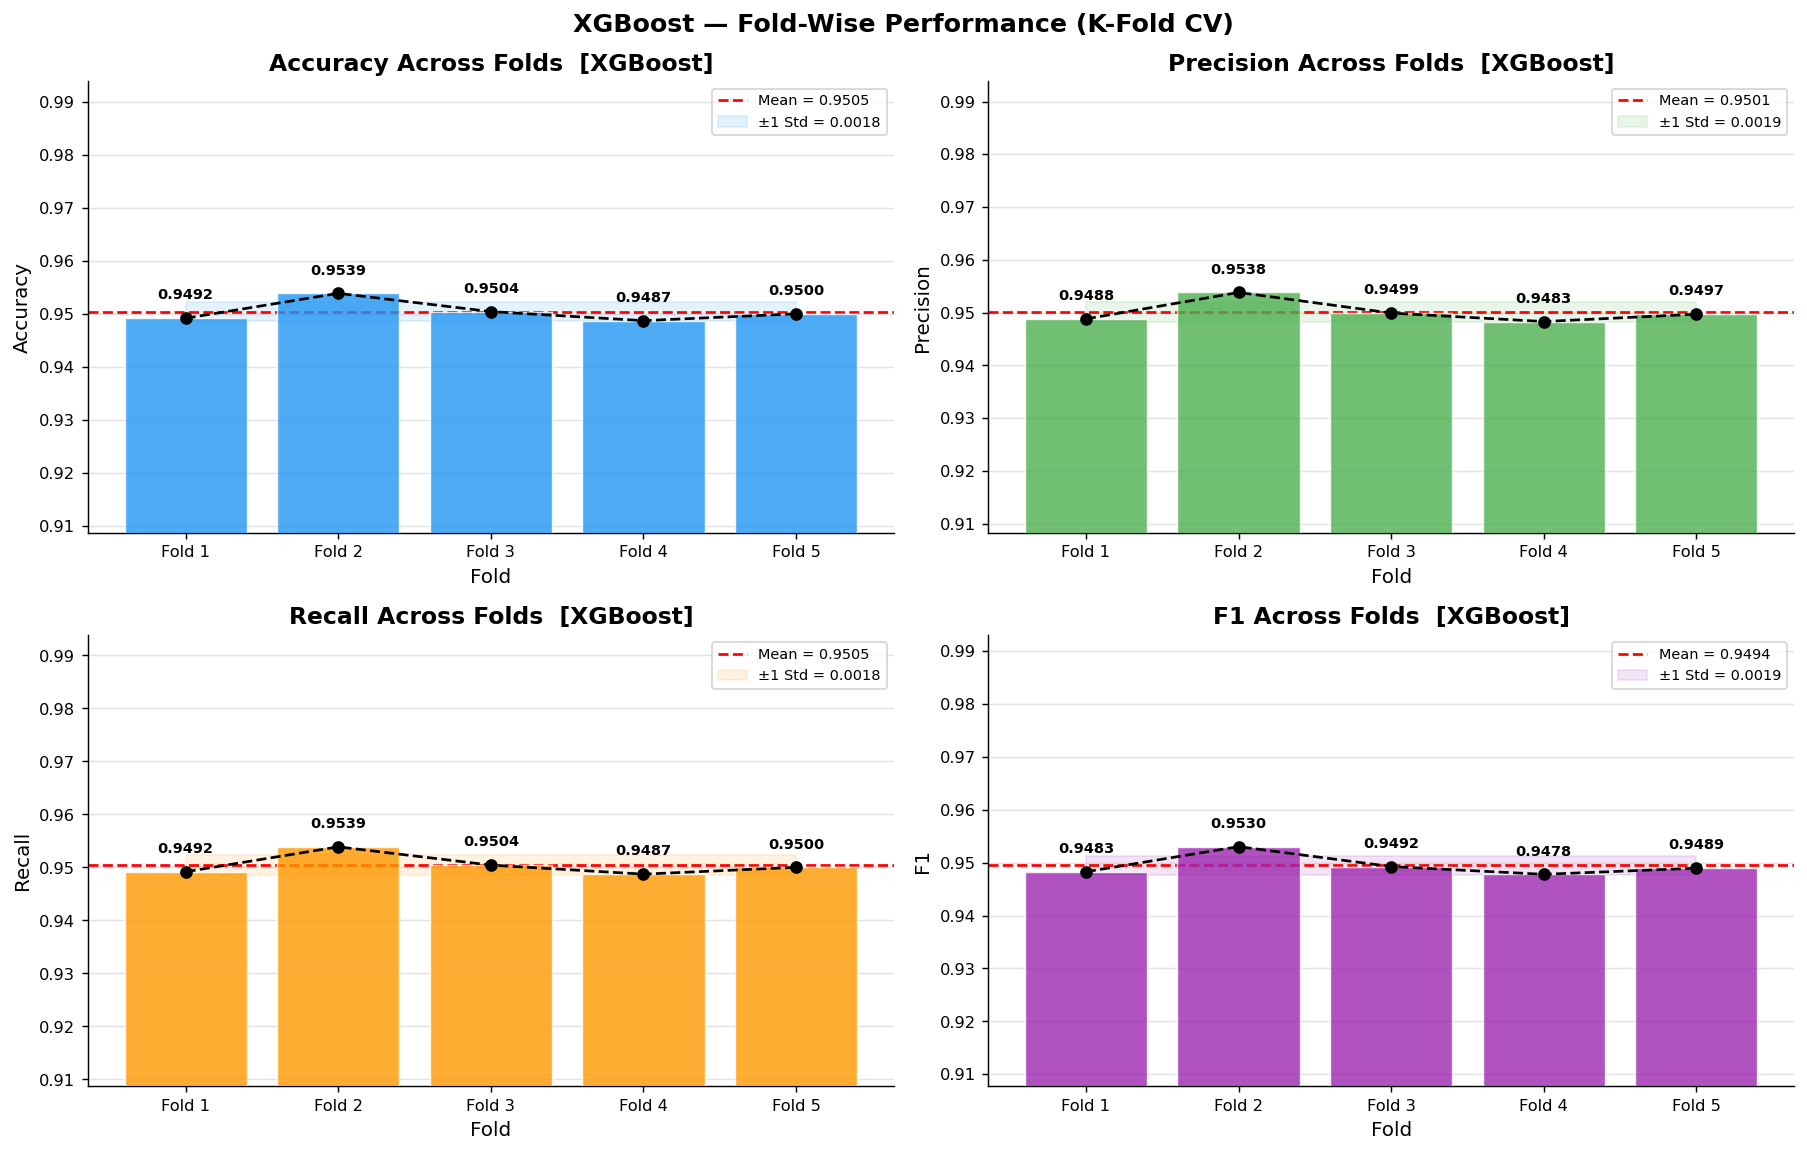

   ✓  foldwise_XGBoost.png saved

  📊  XGBoost Fold Summary:
  Fold  Accuracy  Precision   Recall       F1
Fold 1  0.949190   0.948823 0.949190 0.948263
Fold 2  0.953892   0.953843 0.953892 0.953005
Fold 3  0.950444   0.949939 0.950444 0.949247
Fold 4  0.948738   0.948330 0.948738 0.947775
Fold 5  0.950024   0.949723 0.950024 0.948937
  MEAN  Acc=0.9505  Prec=0.9501  Rec=0.9505  F1=0.9494
  STD   Acc=0.0020  Prec=0.0022  Rec=0.0020  F1=0.0021


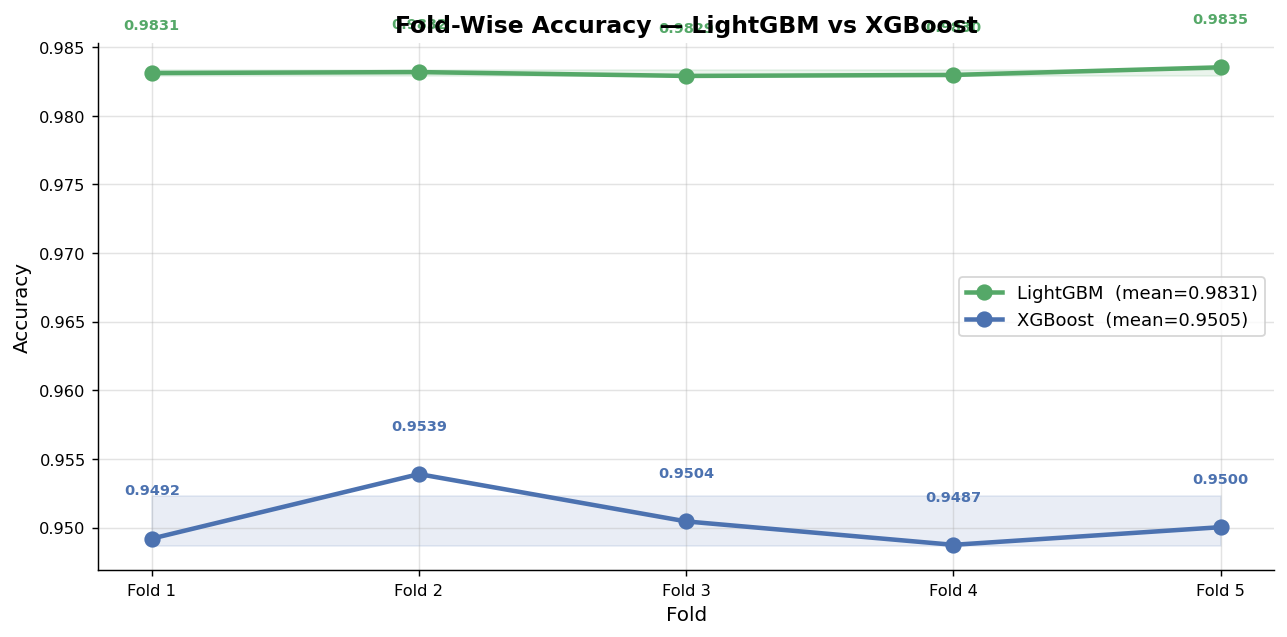

   ✓  foldwise_accuracy_comparison.png saved

[7/7] Extended PCA Analysis …

  📊  Extended PCA Summary:
                      Metric    Value
           Original Features       83
     Selected PCA Components        2
       Variance Retained (%) 99.6717%
Dimensionality Reduction (%) 97.5904%

  📊  Per-Component Variance:
Component  Explained Variance (%)  Cumulative (%)
      PC1               98.734084       98.734084
      PC2                0.937630       99.671714


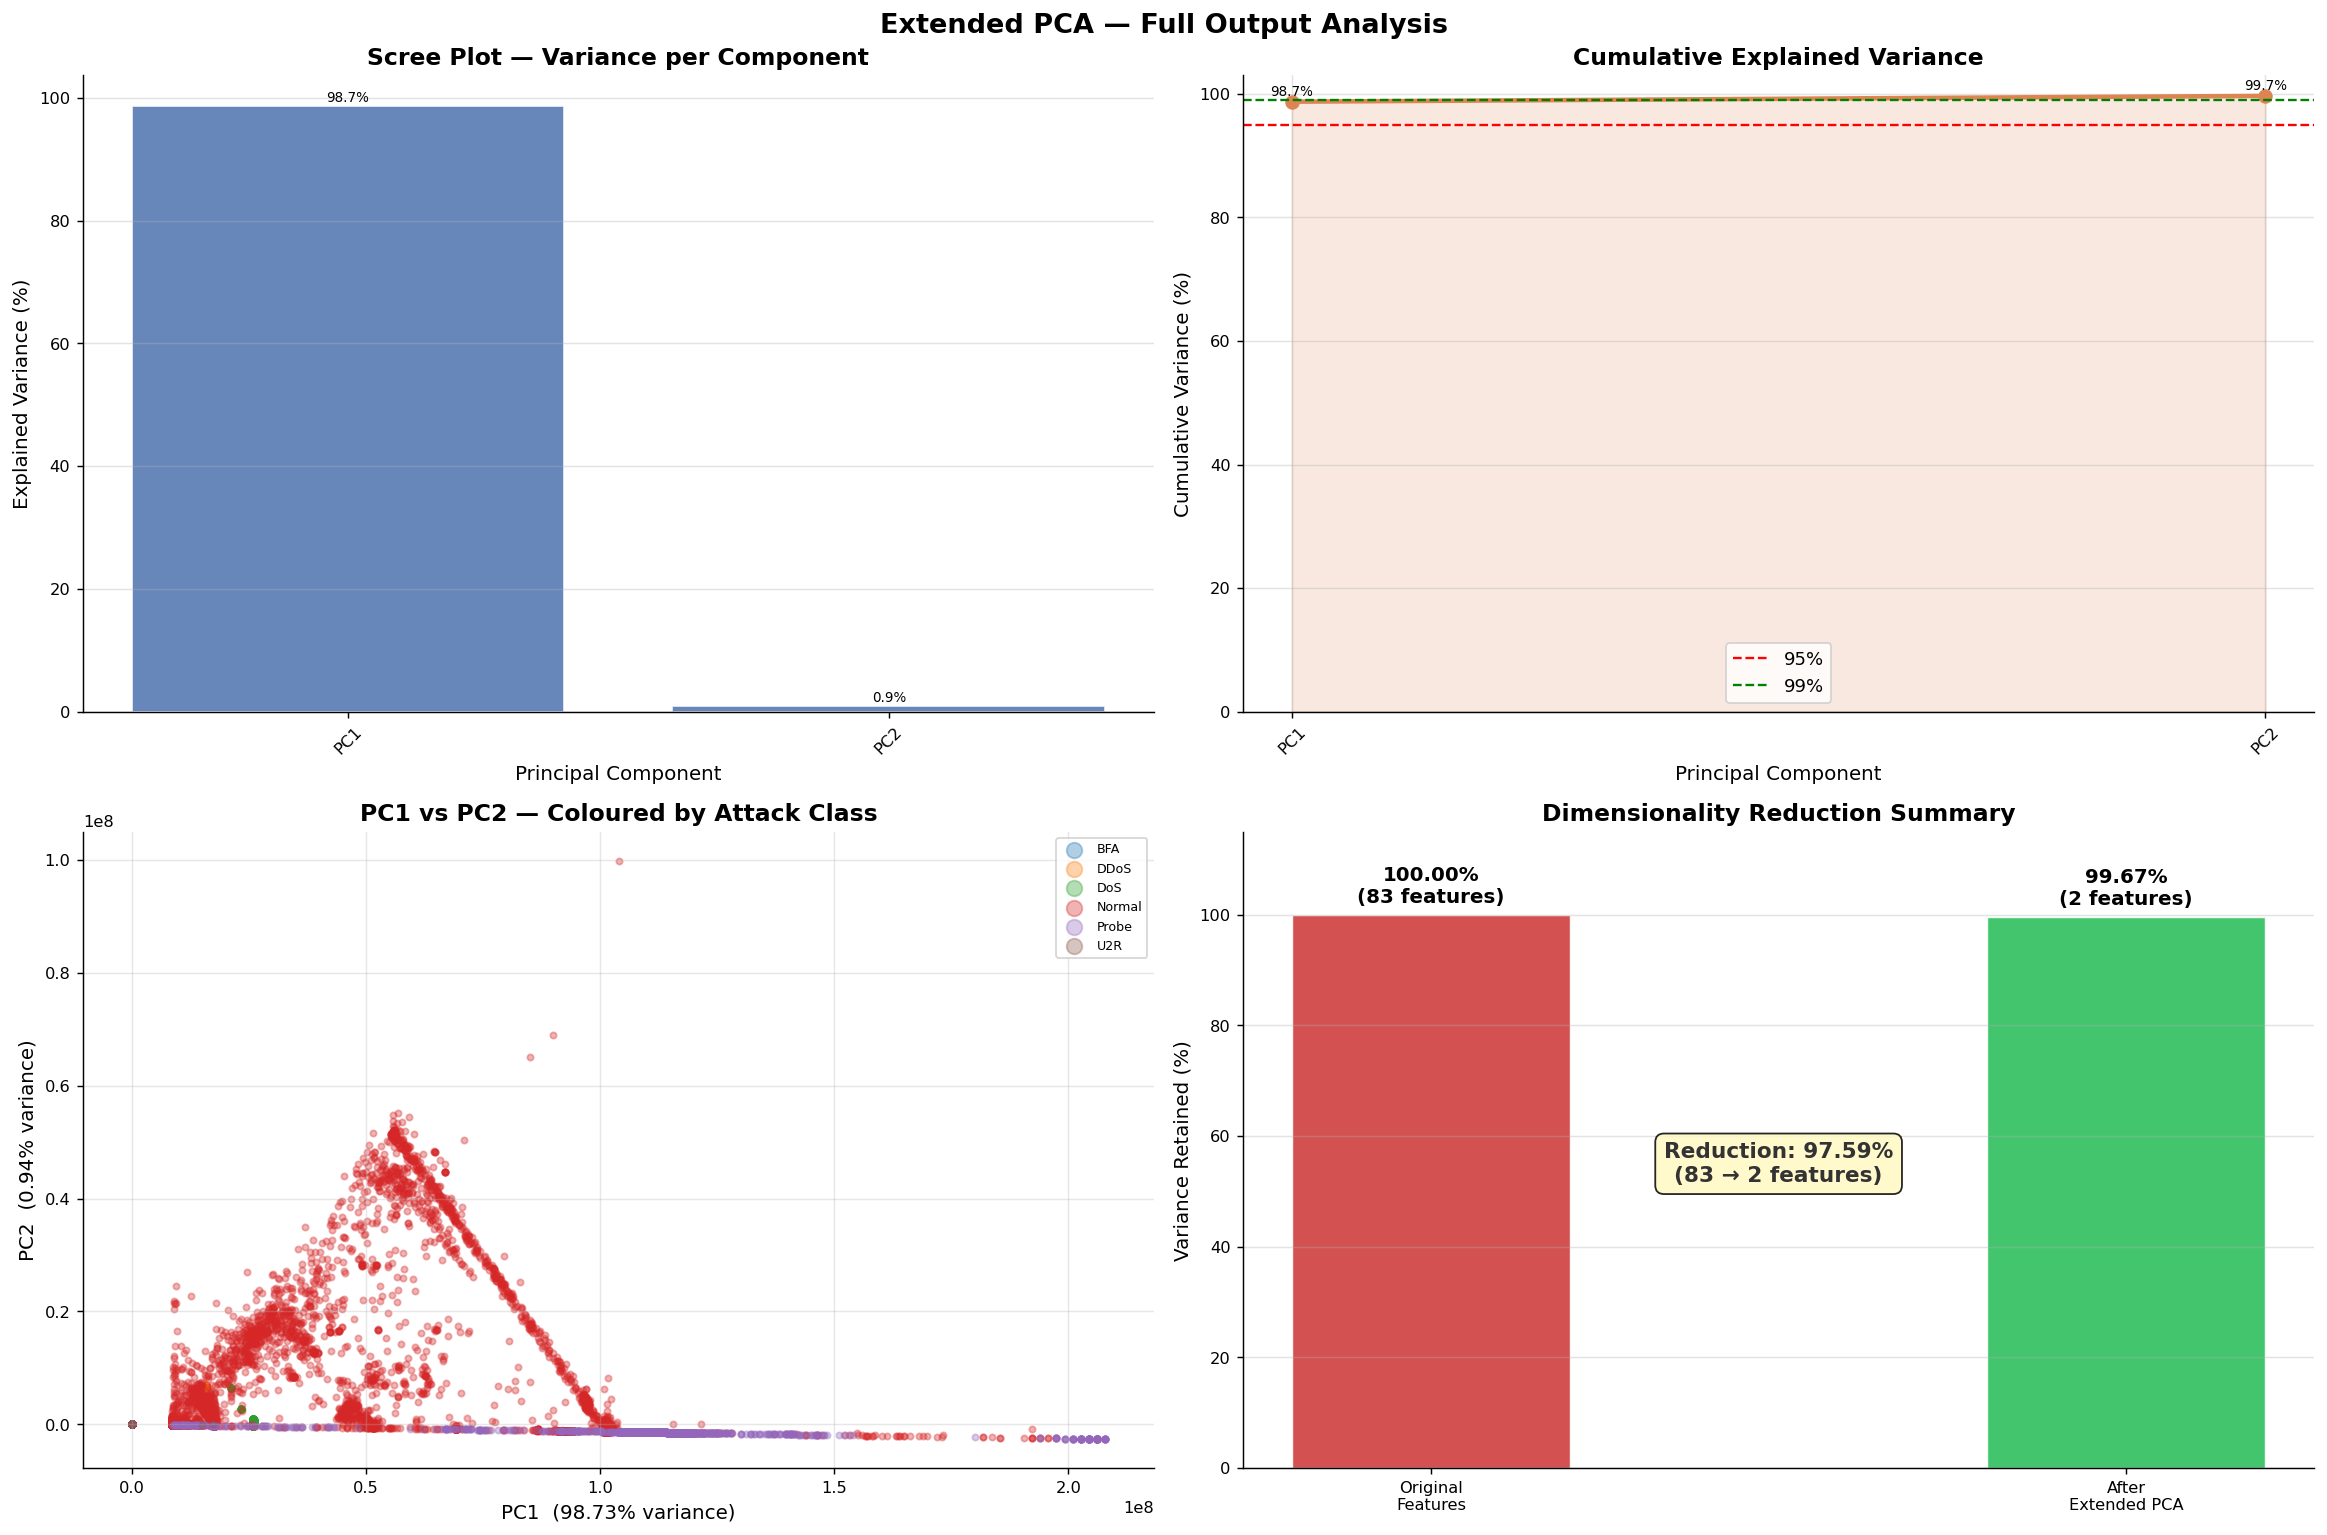

   ✓  extended_pca_analysis.png saved

  MASTER RESULTS SUMMARY — LightGBM & XGBoost
  Dataset          : Metasploitable-2  (70/30 split)
  Original Features: 83
  PCA Components   : 2
  Variance Retained: 99.6717%
  Dim. Reduction   : 97.59%
  Classes (6)      : BFA, DDoS, DoS, Normal, Probe, U2R
----------------------------------------------------------------------
  LightGBM      Acc=96.98%  Prec=0.9695  Rec=0.9698  F1=0.9690
  XGBoost       Acc=94.37%  Prec=0.9435  Rec=0.9437  F1=0.9424


In [13]:
# =============================================================================
# COMPLETE VISUALIZATION & ANALYSIS — XGBoost & LightGBM ONLY
# Self-contained: only needs traindata, testdata, y_train_raw, y_test_raw,
#                 ExtendedPCA class
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# =============================================================================
# ██  BOOTSTRAP — Build all variables from scratch
# =============================================================================

# ── Raw feature arrays ────────────────────────────────────────────────────────
X_train_df  = traindata.iloc[:, :-1].apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_df   = testdata.iloc[:, :-1].apply(pd.to_numeric, errors='coerce').fillna(0)
X_train_raw = X_train_df.values
X_test_raw  = X_test_df.values

# ── Label encoding ────────────────────────────────────────────────────────────
label_encoder   = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
y_test_encoded  = label_encoder.transform(y_test_raw)

# ── Extended PCA ──────────────────────────────────────────────────────────────
epca = ExtendedPCA(n_components=30, variance_threshold=0.99,
                   alpha0=0.5, lambda_decay=0.05, random_state=42)
epca.fit(X_train_raw)
X_train_pca = epca.transform(X_train_raw)
X_test_pca  = epca.transform(X_test_raw)
print(f"✓ PCA: {X_train_raw.shape[1]} features → {X_train_pca.shape[1]} components "
      f"({epca.explained_variance_ratio_.sum()*100:.2f}% variance retained)")

# ── Train XGBoost & LightGBM ──────────────────────────────────────────────────
num_classes = len(np.unique(y_train_encoded))

print("\nTraining LightGBM …")
lgb_model = lgb.LGBMClassifier(
    objective='multiclass', num_class=num_classes,
    n_estimators=200, learning_rate=0.01,
    max_depth=6, num_leaves=63,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, verbose=-1
)
lgb_model.fit(X_train_pca, y_train_encoded,
              eval_set=[(X_test_pca, y_test_encoded)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
lgb_pred = lgb_model.predict(X_test_pca)
print(f"✓ LightGBM accuracy: {accuracy_score(y_test_encoded, lgb_pred)*100:.2f}%")

print("\nTraining XGBoost …")
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax', num_class=num_classes,
    n_estimators=600, learning_rate=0.01,
    max_depth=12, subsample=0.9, colsample_bytree=0.9,
    reg_alpha=0.01, reg_lambda=1.0, gamma=0.0,
    random_state=42, verbosity=0, tree_method='hist', eval_metric='mlogloss'
)
xgb_model.fit(X_train_pca, y_train_encoded,
              eval_set=[(X_test_pca, y_test_encoded)], verbose=False)
xgb_pred = xgb_model.predict(X_test_pca)
print(f"✓ XGBoost accuracy:  {accuracy_score(y_test_encoded, xgb_pred)*100:.2f}%")

# ── Constants ─────────────────────────────────────────────────────────────────
TARGET_NAMES  = [str(cls) for cls in label_encoder.classes_]
N_CLASSES     = len(TARGET_NAMES)
PALETTE       = sns.color_palette("tab10", N_CLASSES)
ALL_PREDS     = {'LightGBM': lgb_pred, 'XGBoost': xgb_pred}
FEATURE_NAMES = [f'PC_{i+1}' for i in range(X_train_pca.shape[1])]

print("\n" + "=" * 70)
print("  VISUALIZATION SUITE  —  LightGBM & XGBoost")
print("=" * 70)


# =============================================================================
# ██  SECTION 1 – HEATMAP BEFORE & AFTER EXTENDED PCA
# =============================================================================

def plot_heatmaps_before_after():
    print("\n[1/7] Heatmaps Before & After PCA …")
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    # Before
    corr_before = pd.DataFrame(X_train_raw).corr()
    sns.heatmap(corr_before, ax=axes[0], cmap='coolwarm', center=0,
                linewidths=0.15, linecolor='grey',
                cbar_kws={'shrink': 0.75, 'label': 'Correlation'},
                xticklabels=False, yticklabels=False)
    axes[0].set_title(f'Feature Correlation  BEFORE  Extended PCA\n'
                      f'({X_train_raw.shape[1]} original features)',
                      fontweight='bold', fontsize=13)
    axes[0].set_xlabel('Feature Index')
    axes[0].set_ylabel('Feature Index')

    # After
    n_comp    = X_train_pca.shape[1]
    pc_labels = [f'PC{i+1}' for i in range(n_comp)]
    corr_after = pd.DataFrame(X_train_pca, columns=pc_labels).corr()
    sns.heatmap(corr_after, ax=axes[1], cmap='coolwarm', center=0,
                linewidths=0.4, linecolor='grey',
                annot=(n_comp <= 20), fmt='.2f',
                cbar_kws={'shrink': 0.75, 'label': 'Correlation'})
    axes[1].set_title(f'Component Correlation  AFTER  Extended PCA\n'
                      f'({n_comp} components  |  '
                      f'{epca.explained_variance_ratio_.sum()*100:.2f}% variance retained)',
                      fontweight='bold', fontsize=13)
    axes[1].set_xlabel('Principal Component')
    axes[1].set_ylabel('Principal Component')

    plt.suptitle('Extended PCA — Before vs After: Feature Correlation Heatmaps',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('heatmap_before_after.png', bbox_inches='tight')
    plt.show()
    print("   ✓  heatmap_before_after.png saved")


# =============================================================================
# ██  SECTION 2 – CONFUSION MATRIX (OVERALL + BY ATTACK TYPE)
# =============================================================================

def plot_confusion_matrices_all(y_true, y_pred_dict):
    print("\n[2/7] Confusion Matrices …")

    for model_name, y_pred in y_pred_dict.items():
        cm      = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        acc     = accuracy_score(y_true, y_pred)

        fig, axes = plt.subplots(
            1, 2,
            figsize=(max(14, N_CLASSES * 1.6), max(6, N_CLASSES * 1.1))
        )
        sns.heatmap(cm, ax=axes[0], annot=True, fmt='d', cmap='Blues',
                    xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                    linewidths=0.4, linecolor='lightgray', cbar_kws={'shrink': 0.8})
        axes[0].set_title(f'{model_name} — Confusion Matrix (Raw Counts)', fontweight='bold')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')
        axes[0].tick_params(axis='x', rotation=45)

        sns.heatmap(cm_norm, ax=axes[1], annot=True, fmt='.2%', cmap='YlOrRd',
                    xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                    linewidths=0.4, linecolor='lightgray',
                    vmin=0, vmax=1, cbar_kws={'shrink': 0.8})
        axes[1].set_title(f'{model_name} — Confusion Matrix (Row-Normalised %)', fontweight='bold')
        axes[1].set_xlabel('Predicted Label')
        axes[1].set_ylabel('True Label')
        axes[1].tick_params(axis='x', rotation=45)

        plt.suptitle(f'{model_name}  |  Overall Accuracy: {acc*100:.2f}%',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        fname = f'confusion_matrix_{model_name}.png'
        plt.savefig(fname, bbox_inches='tight')
        plt.show()
        print(f"   ✓  {fname} saved")

        # Per-class accuracy bar
        class_acc = cm.diagonal() / cm.sum(axis=1)
        fig2, ax2 = plt.subplots(figsize=(max(9, N_CLASSES * 1.2), 5))
        bars = ax2.bar(TARGET_NAMES, class_acc,
                       color=[PALETTE[i] for i in range(N_CLASSES)],
                       edgecolor='white', linewidth=0.7, alpha=0.88)
        ax2.axhline(y=class_acc.mean(), color='black', linestyle='--',
                    linewidth=1.5, label=f'Mean = {class_acc.mean():.4f}')
        ax2.set_ylim(0, 1.08)
        ax2.set_title(f'{model_name} — Per-Class (Attack-Type) Accuracy', fontweight='bold')
        ax2.set_xlabel('Attack Class')
        ax2.set_ylabel('Accuracy')
        ax2.tick_params(axis='x', rotation=45)
        ax2.legend()
        for bar, val in zip(bars, class_acc):
            ax2.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.3f}',
                     ha='center', va='bottom', fontsize=8, fontweight='bold')
        plt.tight_layout()
        fname2 = f'per_class_accuracy_{model_name}.png'
        plt.savefig(fname2, bbox_inches='tight')
        plt.show()
        print(f"   ✓  {fname2} saved")


# =============================================================================
# ██  SECTION 3 – PER-CLASS METRICS (Precision / Recall / F1 / Accuracy)
# =============================================================================

def plot_per_class_metrics(y_true, y_pred_dict):
    print("\n[3/7] Per-Class Metrics …")

    for model_name, y_pred in y_pred_dict.items():
        report    = classification_report(y_true, y_pred, target_names=TARGET_NAMES,
                                          output_dict=True, zero_division=0)
        cm        = confusion_matrix(y_true, y_pred)
        class_acc = cm.diagonal() / cm.sum(axis=1)

        df = pd.DataFrame({
            'Class':     TARGET_NAMES,
            'Precision': [report[c]['precision'] for c in TARGET_NAMES],
            'Recall':    [report[c]['recall']    for c in TARGET_NAMES],
            'F1-Score':  [report[c]['f1-score']  for c in TARGET_NAMES],
            'Accuracy':  class_acc,
            'Support':   [int(report[c]['support']) for c in TARGET_NAMES],
        })
        print(f"\n  📊  {model_name} — Per-Class Metrics:")
        print(df.to_string(index=False))

        metric_cols = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
        colors_bar  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

        fig, axes = plt.subplots(2, 2, figsize=(16, 11))
        for ax, metric, color in zip(axes.flat, metric_cols, colors_bar):
            vals = df[metric].values
            bars = ax.bar(df['Class'], vals, color=color,
                          alpha=0.85, edgecolor='white', linewidth=0.7)
            ax.axhline(y=vals.mean(), color='black', linestyle='--',
                       linewidth=1.3, label=f'Mean = {vals.mean():.4f}')
            ax.set_ylim(0, 1.08)
            ax.set_title(f'{metric} per Attack Type  [{model_name}]', fontweight='bold')
            ax.set_xlabel('Attack Class')
            ax.set_ylabel(metric)
            ax.tick_params(axis='x', rotation=45)
            ax.legend(fontsize=8)
            ax.grid(axis='y', alpha=0.3)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        min(val + 0.012, 1.0), f'{val:.3f}',
                        ha='center', va='bottom', fontsize=7.5, fontweight='bold')

        plt.suptitle(f'{model_name} — Per-Class Metric Variations Across Attack Types',
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        fname = f'per_class_metrics_{model_name}.png'
        plt.savefig(fname, bbox_inches='tight')
        plt.show()
        print(f"   ✓  {fname} saved")


# =============================================================================
# ██  SECTION 4 – ACCURACY / PRECISION / RECALL / F1 COMPARISON GRAPHS
# =============================================================================

def plot_metrics_comparison(y_true, y_pred_dict):
    print("\n[4/7] Metric Comparison Charts …")

    model_names = list(y_pred_dict.keys())
    records = []
    for name, y_pred in y_pred_dict.items():
        records.append({
            'Model':     name,
            'Accuracy':  accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
            'Recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
            'F1-Score':  f1_score(y_true, y_pred, average='weighted', zero_division=0),
        })
    compare_df = pd.DataFrame(records).set_index('Model')

    print("\n  📊  Overall Metrics Comparison:")
    print(compare_df.applymap(lambda x: f'{x*100:.2f}%').to_string())

    metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    bar_colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
    x, width    = np.arange(len(model_names)), 0.18

    fig = plt.figure(figsize=(16, 7))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

    # Grouped bar
    ax1 = fig.add_subplot(gs[0])
    for i, (met, col) in enumerate(zip(metric_cols, bar_colors)):
        offsets = (i - len(metric_cols) / 2 + 0.5) * width
        bars = ax1.bar(x + offsets, compare_df[met], width,
                       label=met, color=col, alpha=0.85, edgecolor='white', linewidth=0.7)
        for bar, val in zip(bars, compare_df[met]):
            ax1.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.005, f'{val:.3f}',
                     ha='center', va='bottom', fontsize=8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, fontsize=12)
    ax1.set_ylim(0, 1.12)
    ax1.set_ylabel('Score')
    ax1.set_title('LightGBM vs XGBoost\nMetric Comparison', fontweight='bold')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(axis='y', alpha=0.35)

    # Radar chart
    ax2 = fig.add_subplot(gs[1], polar=True)
    angles = np.linspace(0, 2 * np.pi, len(metric_cols), endpoint=False).tolist()
    model_colors = ['#55A868', '#4C72B0']
    for (model_name, row), color in zip(compare_df.iterrows(), model_colors):
        vals = row[metric_cols].tolist() + [row[metric_cols[0]]]
        angs = angles + [angles[0]]
        ax2.plot(angs, vals, 'o-', linewidth=2, color=color, label=model_name)
        ax2.fill(angs, vals, alpha=0.15, color=color)
    ax2.set_xticks(angles)
    ax2.set_xticklabels(metric_cols, fontsize=11, fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax2.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=7)
    ax2.set_title('Radar Chart', fontweight='bold', pad=20)
    ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

    plt.suptitle('LightGBM vs XGBoost — Accuracy · Precision · Recall · F1',
                 fontsize=14, fontweight='bold')
    plt.savefig('metrics_comparison.png', bbox_inches='tight')
    plt.show()
    print("   ✓  metrics_comparison.png saved")


# =============================================================================
# ██  SECTION 5 – FEATURE IMPORTANCE GRAPHS
# =============================================================================

def plot_feature_importance(y_pred_dict, top_n=20):
    print("\n[5/7] Feature Importance Graphs …")

    models = {'LightGBM': lgb_model, 'XGBoost': xgb_model}
    top_n  = min(top_n, len(FEATURE_NAMES))

    # Individual horizontal bar charts
    fig, axes = plt.subplots(1, 2, figsize=(18, max(7, top_n * 0.45)))
    colors = {'LightGBM': '#55A868', 'XGBoost': '#4C72B0'}

    for ax, (model_name, model) in zip(axes, models.items()):
        imp = pd.Series(model.feature_importances_,
                        index=FEATURE_NAMES).sort_values(ascending=False).head(top_n)
        ax.barh(imp.index[::-1], imp.values[::-1],
                color=colors[model_name], alpha=0.85, edgecolor='white', linewidth=0.6)
        ax.set_title(f'{model_name} — Feature Importance (Top {top_n})',
                     fontweight='bold', fontsize=12)
        ax.set_xlabel('Importance Score')
        ax.set_ylabel('Principal Component')
        for i, val in enumerate(imp.values[::-1]):
            ax.text(val + imp.values.max() * 0.01, i, f'{val:.1f}', va='center', fontsize=7.5)
        ax.grid(axis='x', alpha=0.35)

    plt.suptitle('Feature Importance — LightGBM vs XGBoost',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('feature_importance_individual.png', bbox_inches='tight')
    plt.show()
    print("   ✓  feature_importance_individual.png saved")

    # Grouped bar (all features side by side)
    n_features = len(FEATURE_NAMES)
    if n_features <= 30:
        lgb_imp = lgb_model.feature_importances_
        xgb_imp = xgb_model.feature_importances_
        order   = np.argsort(lgb_imp + xgb_imp)[::-1]

        fig2, ax = plt.subplots(figsize=(max(12, n_features * 0.6), 6))
        x = np.arange(n_features)
        w = 0.38
        ax.bar(x - w/2, lgb_imp[order], w, label='LightGBM',
               color='#55A868', alpha=0.85, edgecolor='white')
        ax.bar(x + w/2, xgb_imp[order], w, label='XGBoost',
               color='#4C72B0', alpha=0.85, edgecolor='white')
        ax.set_xticks(x)
        ax.set_xticklabels(np.array(FEATURE_NAMES)[order], rotation=45, ha='right', fontsize=8)
        ax.set_title('Feature Importance — LightGBM vs XGBoost (Grouped)',
                     fontweight='bold')
        ax.set_ylabel('Importance Score')
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.35)
        plt.tight_layout()
        plt.savefig('feature_importance_grouped.png', bbox_inches='tight')
        plt.show()
        print("   ✓  feature_importance_grouped.png saved")



# =============================================================================
# ██  SECTION 6 – EXTENDED PCA OUTPUT (Tabular + Graphs)
# =============================================================================

def display_extended_pca_analysis():
    print("\n[7/7] Extended PCA Analysis …")

    n_orig    = X_train_raw.shape[1]
    n_comp    = X_train_pca.shape[1]
    evr       = epca.explained_variance_ratio_
    var_ret   = evr.sum() * 100
    dim_red   = (1 - n_comp / n_orig) * 100
    pc_labels = [f'PC{i+1}' for i in range(n_comp)]

    summary_df = pd.DataFrame({
        'Metric': ['Original Features', 'Selected PCA Components',
                   'Variance Retained (%)', 'Dimensionality Reduction (%)'],
        'Value':  [n_orig, n_comp, f'{var_ret:.4f}%', f'{dim_red:.4f}%']
    })
    print("\n  📊  Extended PCA Summary:")
    print(summary_df.to_string(index=False))

    comp_df = pd.DataFrame({
        'Component':              pc_labels,
        'Explained Variance (%)': evr * 100,
        'Cumulative (%)':         np.cumsum(evr) * 100,
    })
    print("\n  📊  Per-Component Variance:")
    print(comp_df.to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # Scree
    axes[0, 0].bar(pc_labels, comp_df['Explained Variance (%)'],
                   color='#4C72B0', alpha=0.85, edgecolor='white')
    for i, val in enumerate(comp_df['Explained Variance (%)']):
        if val > 0.5:
            axes[0, 0].text(i, val + 0.2, f'{val:.1f}%',
                            ha='center', va='bottom', fontsize=7.5)
    axes[0, 0].set_title('Scree Plot — Variance per Component', fontweight='bold')
    axes[0, 0].set_xlabel('Principal Component')
    axes[0, 0].set_ylabel('Explained Variance (%)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(axis='y', alpha=0.35)

    # Cumulative
    axes[0, 1].plot(pc_labels, comp_df['Cumulative (%)'], 'o-',
                    color='#DD8452', linewidth=2.5, markersize=7)
    axes[0, 1].fill_between(range(n_comp), comp_df['Cumulative (%)'],
                             alpha=0.18, color='#DD8452')
    axes[0, 1].axhline(y=95, color='red', linestyle='--', linewidth=1.3, label='95%')
    axes[0, 1].axhline(y=99, color='green', linestyle='--', linewidth=1.3, label='99%')
    axes[0, 1].set_ylim(0, 103)
    axes[0, 1].set_title('Cumulative Explained Variance', fontweight='bold')
    axes[0, 1].set_xlabel('Principal Component')
    axes[0, 1].set_ylabel('Cumulative Variance (%)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.35)
    for i, val in enumerate(comp_df['Cumulative (%)']):
        axes[0, 1].text(i, val + 0.5, f'{val:.1f}%',
                        ha='center', va='bottom', fontsize=7.5)

    # PC1 vs PC2 scatter
    for cls_idx, (cls_name, color) in enumerate(zip(TARGET_NAMES, PALETTE)):
        mask = (y_train_encoded == cls_idx)
        axes[1, 0].scatter(
            X_train_pca[mask, 0],
            X_train_pca[mask, 1] if n_comp > 1 else np.zeros(mask.sum()),
            c=[color], label=cls_name, alpha=0.35, s=12
        )
    axes[1, 0].set_title('PC1 vs PC2 — Coloured by Attack Class', fontweight='bold')
    axes[1, 0].set_xlabel(f'PC1  ({evr[0]*100:.2f}% variance)')
    axes[1, 0].set_ylabel(f'PC2  ({evr[1]*100:.2f}% variance)' if n_comp > 1 else 'PC2')
    axes[1, 0].legend(fontsize=7, markerscale=2.5, loc='best', ncol=max(1, N_CLASSES // 5))
    axes[1, 0].grid(alpha=0.3)

    # Reduction summary bar
    ax8d = axes[1, 1]
    bars = ax8d.bar(['Original\nFeatures', 'After\nExtended PCA'],
                    [100.0, var_ret], color=['#CC3333', '#22BB55'],
                    alpha=0.85, edgecolor='white', linewidth=0.8, width=0.4)
    ax8d.set_ylim(0, 115)
    ax8d.set_ylabel('Variance Retained (%)')
    ax8d.set_title('Dimensionality Reduction Summary', fontweight='bold')
    for bar, val, feats in zip(bars, [100.0, var_ret], [n_orig, n_comp]):
        ax8d.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
                  f'{val:.2f}%\n({feats} features)',
                  ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax8d.text(0.5, 55, f'Reduction: {dim_red:.2f}%\n({n_orig} → {n_comp} features)',
              ha='center', va='center', fontsize=12, color='#333333', fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', alpha=0.85))
    ax8d.grid(axis='y', alpha=0.35)

    plt.suptitle('Extended PCA — Full Output Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('extended_pca_analysis.png', bbox_inches='tight')
    plt.show()
    print("   ✓  extended_pca_analysis.png saved")


# =============================================================================
# ██  MASTER RUN
# =============================================================================

plot_heatmaps_before_after()
plot_confusion_matrices_all(y_test_encoded, ALL_PREDS)
plot_per_class_metrics(y_test_encoded, ALL_PREDS)
plot_metrics_comparison(y_test_encoded, ALL_PREDS)
plot_feature_importance(ALL_PREDS)
run_foldwise_evaluation(n_folds=5)
display_extended_pca_analysis()


# =============================================================================
# ██  MASTER SUMMARY TABLE
# =============================================================================

print("\n" + "=" * 70)
print("  MASTER RESULTS SUMMARY — LightGBM & XGBoost")
print("=" * 70)
print(f"  Dataset          : Metasploitable-2  (70/30 split)")
print(f"  Original Features: {X_train_raw.shape[1]}")
print(f"  PCA Components   : {X_train_pca.shape[1]}")
print(f"  Variance Retained: {epca.explained_variance_ratio_.sum()*100:.4f}%")
print(f"  Dim. Reduction   : {(1 - X_train_pca.shape[1]/X_train_raw.shape[1])*100:.2f}%")
print(f"  Classes ({N_CLASSES})      : {', '.join(TARGET_NAMES)}")
print("-" * 70)
for model_name, y_pred in ALL_PREDS.items():
    acc  = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test_encoded, y_pred, average='weighted', zero_division=0)
    print(f"  {model_name:<12}  Acc={acc*100:.2f}%  Prec={prec:.4f}  "
          f"Rec={rec:.4f}  F1={f1:.4f}")
print("=" * 70)